In [928]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.neighbors import KNeighborsClassifier
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor

sys.path.insert(0, str(Path.cwd().parent))

from utils.geo import BBox, inside_bbox_mask, single_bbox_inside, CUNDINAMARCA_BBOX, count_outside_bogota
from utils.triple_plot import normality_report


In [929]:
df = pd.read_csv("../data/fincaraiz_venta_bogota_20260803.csv")

In [930]:
initial_df = df.copy()

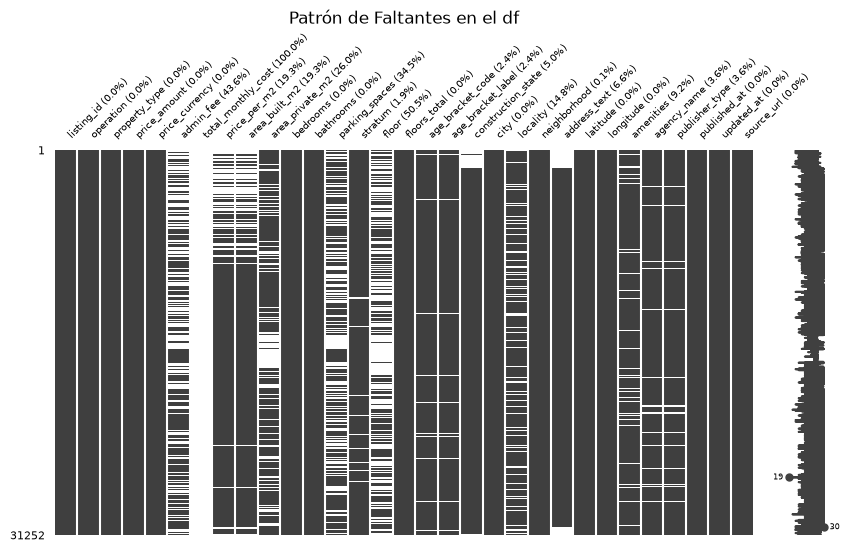

In [931]:
n_cols = len(df.columns)
ancho = max(10, int(n_cols * 0.35))
alto = 5

tamano_letra = max(6, 10 - n_cols // 10)

# Porcentaje de nulos por columna
pct_nulos = df.isnull().mean() * 100

try:
    ax = (
        msno.matrix(df, figsize=(ancho, alto), fontsize=tamano_letra)
        or plt.gca()
    )
    plt.title("Patrón de Faltantes en el df")

    if len(ax.get_xticks()) == n_cols:
        ax.set_xticks(range(n_cols))
        ax.set_xticklabels(
            [f"{c} ({p:.1f}%)" for c, p in zip(df.columns, pct_nulos)],
            rotation=45,
            ha="left",
            fontsize=tamano_letra,
        )

    plt.show()

except Exception:
    plt.figure(figsize=(ancho, alto))
    missing_pattern = df.isnull()

    plt.imshow(missing_pattern.astype(int), aspect="auto", cmap="RdYlGn_r")

    plt.xticks(
        ticks=range(n_cols),
        labels=[
            f"{c} ({p:.1f}%)"
            for c, p in zip(missing_pattern.columns, pct_nulos)
        ],
        rotation=90,
        fontsize=tamano_letra,
        ha="center",
    )
    plt.yticks([])
    plt.title("Patrón de Faltantes (blanco = faltante)")
    plt.colorbar(label="1=Faltante, 0=Presente")

    plt.tight_layout()  # Evita que las etiquetas se corten abajo
    plt.show()

# Drop useless columns

In [932]:
df.columns

Index(['listing_id', 'operation', 'property_type', 'price_amount',
       'price_currency', 'admin_fee', 'total_monthly_cost', 'price_per_m2',
       'area_built_m2', 'area_private_m2', 'bedrooms', 'bathrooms',
       'parking_spaces', 'stratum', 'floor', 'floors_total',
       'age_bracket_code', 'age_bracket_label', 'construction_state', 'city',
       'locality', 'neighborhood', 'address_text', 'latitude', 'longitude',
       'amenities', 'agency_name', 'publisher_type', 'published_at',
       'updated_at', 'source_url'],
      dtype='str')

In [933]:
useful_columns = [
    "listing_id",
    "operation",
    "source_url",
    "total_monthly_cost",
    "address_text",
]

df.drop(columns=useful_columns, inplace=True)

In [934]:
df.columns

Index(['property_type', 'price_amount', 'price_currency', 'admin_fee',
       'price_per_m2', 'area_built_m2', 'area_private_m2', 'bedrooms',
       'bathrooms', 'parking_spaces', 'stratum', 'floor', 'floors_total',
       'age_bracket_code', 'age_bracket_label', 'construction_state', 'city',
       'locality', 'neighborhood', 'latitude', 'longitude', 'amenities',
       'agency_name', 'publisher_type', 'published_at', 'updated_at'],
      dtype='str')

In [935]:
df[df["price_currency"] == "U$S"]
# there's a single row with a different currency, we will drop it.
# that row is full of NaN values, also is kinda weird that the price is in
# dollars but the property is in ciudad bolivar.
# by the way, the column price_currency is useless since all the other rows
# have the same value, so we will drop it too.

,property_type,price_amount,price_currency,admin_fee,price_per_m2,area_built_m2,area_private_m2,bedrooms,bathrooms,parking_spaces,...,city,locality,neighborhood,latitude,longitude,amenities,agency_name,publisher_type,published_at,updated_at
512,casa,190000000.00,U$S,NaN,NaN,NaN,216.00,8,3,NaN,...,Bogotá,Ciudad Bolivar,Compartir,4.56,-74.15,Baño Auxiliar|Colegios / Universidades|Instala...,NaN,NaN,2024-02-19,2026-07-22


In [936]:
df = df[df["price_currency"] != "U$S"]
df.drop(columns=["price_currency"], inplace=True)
df.head()

,property_type,price_amount,admin_fee,price_per_m2,area_built_m2,area_private_m2,bedrooms,bathrooms,parking_spaces,stratum,...,city,locality,neighborhood,latitude,longitude,amenities,agency_name,publisher_type,published_at,updated_at
0,casa,880000000.00,736000.00,5500000.00,160.00,151.00,3,3,2.00,4.00,...,Bogotá,Suba,UB. Hacienda Cordoba Niza,4.71,-74.06,Alarma|Baño Auxiliar|Calentador|Canchas Deport...,NaN,NaN,2023-01-24,2026-06-16
1,casa,650000000.00,NaN,4237288.14,153.40,153.40,4,2,1.00,3.00,...,Bogotá,Barrios Unidos,Benjamin Herrera,4.66,-74.07,Baño Auxiliar|Colegios / Universidades|Estudio...,NaN,NaN,2023-01-31,2026-07-24
2,casa,625000000.00,643500.00,5208333.33,120.00,120.00,4,3,2.00,5.00,...,Bogotá,Usaquen,Lagos DE Torca,4.76,-74.04,Baño Auxiliar|Calentador|Cancha de Tennis|Canc...,NaN,NaN,2023-02-08,2026-06-18
3,oficina,830000000.00,1305000.00,9120879.12,91.00,91.00,1,1,2.00,6.00,...,Bogotá,NaN,Chicó Reservado,4.68,-74.05,Ascensor|Baños comunales|Cableado de Red|Circu...,NaN,NaN,2023-02-16,2026-07-19
4,apartamento,470000000.00,560000.00,8392857.14,56.00,58.00,1,2,1.00,4.00,...,Bogotá,Usaquen,Cedritos,4.72,-74.04,Ascensor|Barra estilo americano|Baño Auxiliar|...,NaN,NaN,2023-03-01,2026-07-21


# Drop comercial properties. 

since we are only interested in residential ones.

In [937]:
useful_properties = [
    "casa",
    "apartamento",
    "apartaestudio",
    "casa_campestre",
    "habitacion",
    "finca",
    "cabana",
]

In [938]:
df = df.loc[df["property_type"].isin(useful_properties)]

In [939]:
df.head()

,property_type,price_amount,admin_fee,price_per_m2,area_built_m2,area_private_m2,bedrooms,bathrooms,parking_spaces,stratum,...,city,locality,neighborhood,latitude,longitude,amenities,agency_name,publisher_type,published_at,updated_at
0,casa,880000000.00,736000.00,5500000.00,160.00,151.00,3,3,2.00,4.00,...,Bogotá,Suba,UB. Hacienda Cordoba Niza,4.71,-74.06,Alarma|Baño Auxiliar|Calentador|Canchas Deport...,NaN,NaN,2023-01-24,2026-06-16
1,casa,650000000.00,NaN,4237288.14,153.40,153.40,4,2,1.00,3.00,...,Bogotá,Barrios Unidos,Benjamin Herrera,4.66,-74.07,Baño Auxiliar|Colegios / Universidades|Estudio...,NaN,NaN,2023-01-31,2026-07-24
2,casa,625000000.00,643500.00,5208333.33,120.00,120.00,4,3,2.00,5.00,...,Bogotá,Usaquen,Lagos DE Torca,4.76,-74.04,Baño Auxiliar|Calentador|Cancha de Tennis|Canc...,NaN,NaN,2023-02-08,2026-06-18
4,apartamento,470000000.00,560000.00,8392857.14,56.00,58.00,1,2,1.00,4.00,...,Bogotá,Usaquen,Cedritos,4.72,-74.04,Ascensor|Barra estilo americano|Baño Auxiliar|...,NaN,NaN,2023-03-01,2026-07-21
5,casa,3300000000.00,NaN,NaN,NaN,350.00,4,3,2.00,6.00,...,Bogotá,Suba,San Jose DE Bavaria,4.77,-74.06,Balcón|Barra estilo americano|Baño Auxiliar|Ch...,Dávila Peña y CIA SAS,inmobiliaria,2023-03-22,2026-06-13


## Reevaluate the missing data pattern after cleaning comercial properties

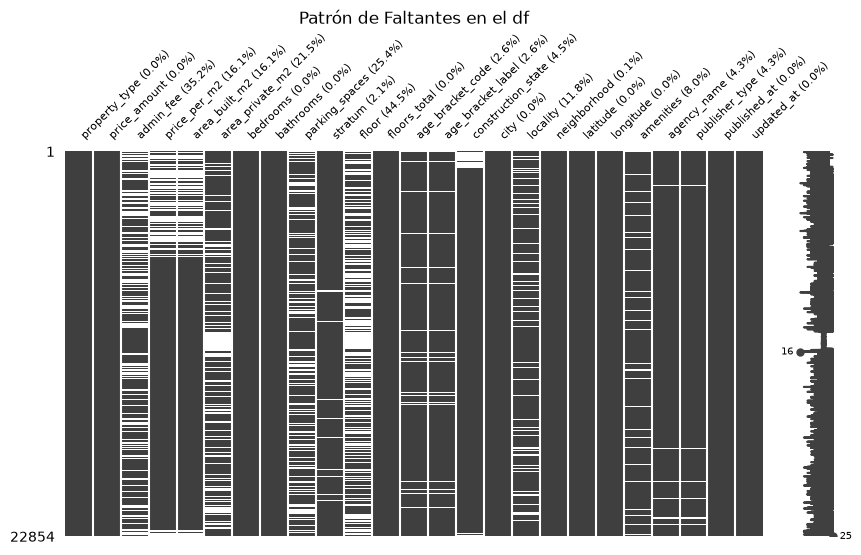

In [940]:
n_cols = len(df.columns)
ancho = max(10, int(n_cols * 0.35))
alto = 5

tamano_letra = max(6, 10 - n_cols // 10)

# Porcentaje de nulos por columna
pct_nulos = df.isnull().mean() * 100

try:
    ax = (
        msno.matrix(df, figsize=(ancho, alto), fontsize=tamano_letra)
        or plt.gca()
    )
    plt.title("Patrón de Faltantes en el df")

    if len(ax.get_xticks()) == n_cols:
        ax.set_xticks(range(n_cols))
        ax.set_xticklabels(
            [f"{c} ({p:.1f}%)" for c, p in zip(df.columns, pct_nulos)],
            rotation=45,
            ha="left",
            fontsize=tamano_letra,
        )

    plt.show()

except Exception:
    plt.figure(figsize=(ancho, alto))
    missing_pattern = df.isnull()

    plt.imshow(missing_pattern.astype(int), aspect="auto", cmap="RdYlGn_r")

    plt.xticks(
        ticks=range(n_cols),
        labels=[
            f"{c} ({p:.1f}%)"
            for c, p in zip(missing_pattern.columns, pct_nulos)
        ],
        rotation=90,
        fontsize=tamano_letra,
        ha="center",
    )
    plt.yticks([])
    plt.title("Patrón de Faltantes (blanco = faltante)")
    plt.colorbar(label="1=Faltante, 0=Presente")

    plt.tight_layout()  # Evita que las etiquetas se corten abajo
    plt.show()

In [941]:
# 1. Row counts
len_initial = len(initial_df)
len_final = len(df)

# 2. Calculate null rates (%) relative to total rows in each DataFrame
initial_rate = (initial_df.isna().sum() / len_initial) * 100
final_rate = (df.isna().sum() / len_final) * 100

# 3. Combine into summary DataFrame
null_rate_summary = pd.DataFrame(
    {"Initial_Null_Rate (%)": initial_rate, "Final_Null_Rate (%)": final_rate}
)


null_rate_summary["Pct_Points_Reduced"] = (
    null_rate_summary["Initial_Null_Rate (%)"]
    - null_rate_summary["Final_Null_Rate (%)"]
)


null_rate_summary["Relative_Improvement (%)"] = np.where(
    null_rate_summary["Initial_Null_Rate (%)"] > 0,
    (
        null_rate_summary["Pct_Points_Reduced"]
        / null_rate_summary["Initial_Null_Rate (%)"]
    )
    * 100,
    0.0,
)


null_rate_summary = null_rate_summary.round(2)

print(f"Total Rows: Initial = {len_initial:,} | Final = {len_final:,}\n")
null_rate_summary

Total Rows: Initial = 31,252 | Final = 22,854



,Initial_Null_Rate (%),Final_Null_Rate (%),Pct_Points_Reduced,Relative_Improvement (%)
address_text,6.61,NaN,NaN,NaN
admin_fee,43.55,35.20,8.35,19.17
age_bracket_code,2.44,2.62,-0.18,-7.32
age_bracket_label,2.44,2.62,-0.18,-7.32
agency_name,3.57,4.29,-0.72,-20.19
amenities,9.20,8.00,1.20,13.01
area_built_m2,19.35,16.07,3.28,16.95
area_private_m2,25.99,21.52,4.47,17.19
bathrooms,0.00,0.00,0.00,0.00
bedrooms,0.00,0.00,0.00,0.00


in general, the null rates have decreased significantly, especially in columns that were dropped or filtered. The relative improvement column shows the percentage of the original null rate that has been eliminated through the cleaning process.

despite of that, there are some colums that increased their null rate: 

* `age_bracket_code` (-7.32)
* `age_bracket_label` (-7.32)
* `agency_name` (-20.19)
* `city` (-17.21) -> actually, this one is easy to fill, maybe it could also consider zipa or chia as cities.
* `neighborhood` (-4.57) -> it could be inputed using coordinates
* `publisher_type` (-20.19)
* `stratum` (-12.80) -> also will be imputed using coordinates and BBOX.



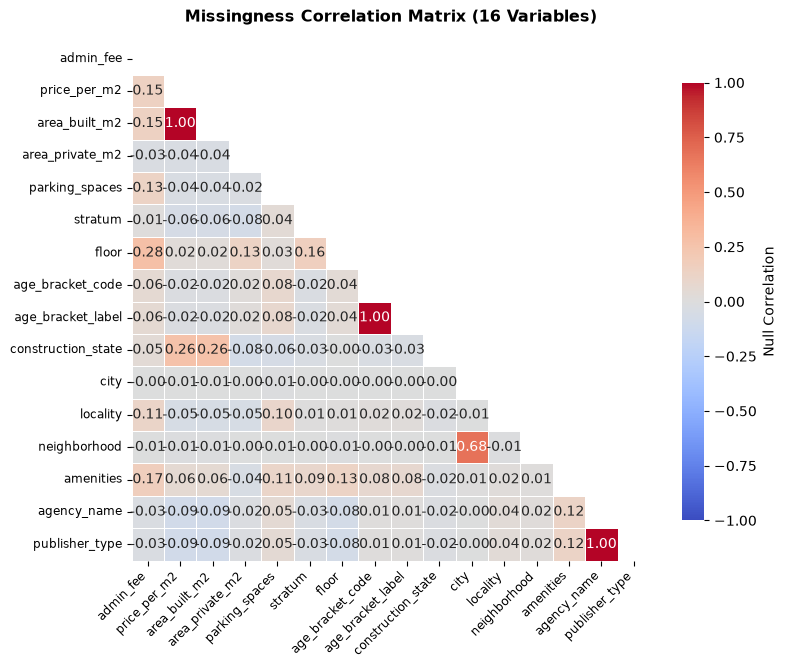

In [942]:
# 1. Extract missing indicators and remove constant/zero-variance columns
cols_with_nulls = [col for col in df.columns if df[col].isnull().sum() > 0]
missing_df = df[cols_with_nulls].isnull().astype(int)

# Drop columns with zero variance (e.g., 0% or 100% missing)
missing_df = missing_df.loc[:, missing_df.std() > 0]

# 2. Compute correlation matrix
missing_corr = missing_df.corr()
n_vars = missing_corr.shape[1]

# 3. Dynamic sizing & settings based on variable count
fig_size = max(7, n_vars * 0.5)
show_annot = n_vars <= 15  # Only annotate numbers if 15 or fewer variables
font_scale = max(6, min(10, 120 / n_vars))  # Scale label font size

plt.figure(figsize=(fig_size, fig_size * 0.85))

# Mask upper triangle + diagonal
mask = np.triu(np.ones_like(missing_corr, dtype=bool))

# 4. Plot heatmap
sns.heatmap(
    missing_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5 if n_vars <= 30 else 0,
    cbar_kws={"shrink": 0.8, "label": "Null Correlation"},
    annot_kws={"size": font_scale} if show_annot else None,
)

# 5. Format labels
plt.xticks(rotation=45, ha="right", fontsize=font_scale + 1)
plt.yticks(rotation=0, fontsize=font_scale + 1)
plt.title(
    f"Missingness Correlation Matrix ({n_vars} Variables)",
    fontsize=font_scale + 4,
    pad=15,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

# Clean or re-code discrete variables

there are some logic issues

In [943]:
discrete_columns = [
    "bedrooms",
    "bathrooms",
    "parking_spaces",
    "floor",
    "floors_total",
    "stratum",

]

## Bedrooms

In [944]:
df["bedrooms"].value_counts()

bedrooms
 3     8385
 4     4413
 2     3497
 1     2574
 5     1478
 6      704
 7      411
 8      362
 9      230
 10     206
 0      167
 11     117
 12      86
 13      49
 14      42
 15      35
 20      26
 19      16
 18      15
 16      14
 17      12
-1       12
 22       1
 21       1
 33       1
Name: count, dtype: int64

In [945]:
weird_bedrooms_num = [-1, 0, 33, 20]

In [946]:
for i in weird_bedrooms_num:
    print(f"Conteo para {i}:  {df[df['bedrooms'] == i].shape[0]}")

Conteo para -1:  12
Conteo para 0:  167
Conteo para 33:  1
Conteo para 20:  26


The properties without bedrooms actually are NaN since -1 is a input error also shuld be considered a NaN

In [947]:
df['bedrooms'] = df['bedrooms'].replace([-1, 0], np.nan)

In [948]:
df['bedrooms'].isnull().sum()

np.int64(179)

## bathrooms

In [949]:
df['bathrooms'].value_counts()

bathrooms
2     6336
3     4723
1     3903
4     3854
5     2458
6      814
7      288
0      142
8      138
10     113
9       63
11       7
20       4
13       4
12       2
80       1
16       1
15       1
18       1
14       1
Name: count, dtype: int64

In [950]:
df['bathrooms'] = df['bathrooms'].replace(0, np.nan)
# 0 as well is a nan

## parking_spaces

In [951]:
df['parking_spaces'].isnull().sum()

np.int64(5815)

In [952]:
df['parking_spaces'].value_counts()

parking_spaces
1.00      6363
2.00      5641
4.00      2170
3.00      2017
6.00       320
5.00       291
8.00        79
7.00        56
10.00       46
11.00       17
9.00        17
12.00        5
-1.00        4
15.00        3
13.00        2
17.00        2
127.00       2
-2.00        2
21.00        1
19.00        1
Name: count, dtype: int64

In [953]:
df['parking_spaces'] = df['parking_spaces'].replace({-1: 1, -2: 2})

## floor

In [954]:
df['floor'].isnull().sum()

np.int64(10171)

In [955]:
df['floor'].value_counts()

floor
2.00      2394
3.00      2153
1.00      2043
4.00      1612
5.00      1376
6.00       729
7.00       492
8.00       311
18.00      262
9.00       212
12.00      192
10.00      186
11.00      173
16.00       99
13.00       96
14.00       88
15.00       87
17.00       46
20.00       21
19.00       20
21.00       14
22.00       12
27.00        7
24.00        6
23.00        6
29.00        6
25.00        5
28.00        4
32.00        3
101.00       3
301.00       3
26.00        3
102.00       2
203.00       2
30.00        2
502.00       2
501.00       1
402.00       1
403.00       1
801.00       1
505.00       1
404.00       1
303.00       1
701.00       1
601.00       1
608.00       1
35.00        1
Name: count, dtype: int64

In [956]:
df['floor'] = df['floor'].apply(lambda x: round(x/100, 0) if x > 100 else x)

## floors_total

maybe we should drop it and only use floor since its more consistent

In [957]:
df['floors_total'].isnull().sum()

np.int64(0)

In [958]:
df['floors_total'].value_counts()

floors_total
0      16300
1       2182
2       1227
3       1120
5        429
4        412
6        332
7        149
12       131
8         92
10        79
9         52
17        44
18        37
16        33
20        33
13        28
14        28
11        26
15        24
19        14
24        13
22        11
21        10
23         8
25         8
30         8
27         7
28         4
26         4
101        1
40         1
35         1
31         1
32         1
29         1
34         1
36         1
33         1
Name: count, dtype: int64

In [959]:
df['floors_total'] = df['floors_total'].replace(0, np.nan)
# as well are nan

## stratum

In [960]:
df['stratum'].value_counts()

stratum
3.00      5773
4.00      5235
6.00      4963
5.00      4762
2.00      1441
1.00        91
110.00      85
7.00         8
100.00       6
Name: count, dtype: int64

In [961]:
stratum_mask = df['stratum'] > 6

In [962]:
stratum_mask.sum()
# those rows will be deleted since some houses whose stratum is 110 actually
# are stratum 1 and other ones are stratum 6.

np.int64(99)

In [963]:
df = df[~stratum_mask]

# Looking for MAR mechanisms

In [964]:
cols_with_nulls = [col for col in df.columns if df[col].isnull().any()]

In [965]:
cols_with_nulls, df.columns

(['admin_fee',
  'price_per_m2',
  'area_built_m2',
  'area_private_m2',
  'bedrooms',
  'bathrooms',
  'parking_spaces',
  'stratum',
  'floor',
  'floors_total',
  'age_bracket_code',
  'age_bracket_label',
  'construction_state',
  'city',
  'locality',
  'neighborhood',
  'amenities',
  'agency_name',
  'publisher_type'],
 Index(['property_type', 'price_amount', 'admin_fee', 'price_per_m2',
        'area_built_m2', 'area_private_m2', 'bedrooms', 'bathrooms',
        'parking_spaces', 'stratum', 'floor', 'floors_total',
        'age_bracket_code', 'age_bracket_label', 'construction_state', 'city',
        'locality', 'neighborhood', 'latitude', 'longitude', 'amenities',
        'agency_name', 'publisher_type', 'published_at', 'updated_at'],
       dtype='str'))

convert dates to datetime types

In [966]:
df['pub_month'] = pd.to_datetime(df['published_at']).dt.to_period('M')
df['mod_month'] = pd.to_datetime(df['updated_at']).dt.to_period('M')

In [967]:
df = df[df["property_type"] != "cabana"]  # since there's only one row with
# this property type, we will drop it.

In [968]:
def get_cramers_v_label(v: float) -> str:
    if v < 0.10:
        return "Negligible"
    elif v < 0.30:
        return "Small"
    elif v < 0.50:
        return "Medium"
    else:
        return "Large"


def get_cohens_d_label(d: float) -> str:
    abs_d = abs(d)
    if abs_d < 0.20:
        return "Negligible"
    elif abs_d < 0.50:
        return "Small"
    elif abs_d < 0.80:
        return "Medium"
    else:
        return "Large"


def analyze_missingness_mar(
    df: pd.DataFrame, target_col: str, cat_col: str, alpha: float = 0.05
) -> dict:
    is_missing = df[target_col].isnull()
    contingency_table = pd.crosstab(df[cat_col], is_missing)

    chi2, p_value, dof, _ = stats.chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    k = contingency_table.shape[0]

    # Cramér's V calculation
    denom = n * min(k - 1, 1)
    cramers_v = np.sqrt(chi2 / denom) if denom > 0 else 0.0

    return {
        "target_col (examined one)": target_col,
        "predictor_col": cat_col,
        "predictor_type": "Categorical",
        "stat_test": "Chi-Square",
        "statistic": chi2,
        "p_value": p_value,
        "is_mar": p_value < alpha,
        "effect_size": cramers_v,
        "effect_size_type": "Cramér's V",
        "effect_magnitude": get_cramers_v_label(cramers_v),
    }


def analyze_missingness_mar_continuous(
    df: pd.DataFrame, target_col: str, cont_col: str, alpha: float = 0.05
) -> dict:
    is_missing = df[target_col].isnull()
    vals_present = df.loc[~is_missing, cont_col].dropna()
    vals_missing = df.loc[is_missing, cont_col].dropna()

    stat, p_value = stats.mannwhitneyu(
        vals_present, vals_missing, alternative="two-sided"
    )

    # Cohen's d calculation
    n1, n2 = len(vals_present), len(vals_missing)
    s1, s2 = vals_present.std(), vals_missing.std()

    if n1 > 1 and n2 > 1:
        s_pooled = np.sqrt(
            ((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2)
        )
        cohens_d = (
            (vals_present.mean() - vals_missing.mean()) / s_pooled
            if s_pooled > 0
            else 0.0
        )
    else:
        cohens_d = 0.0

    return {
        "target_col (examined one)": target_col,
        "predictor_col": cont_col,
        "predictor_type": "Continuous",
        "stat_test": "Mann-Whitney U",
        "statistic": stat,
        "p_value": p_value,
        "is_mar": p_value < alpha,
        "effect_size": abs(cohens_d),
        "effect_size_type": "Cohen's d",
        "effect_magnitude": get_cohens_d_label(cohens_d),
    }

In [969]:
df.drop(columns=['published_at', 'updated_at'], inplace=True)

In [970]:
df.info()

<class 'pandas.DataFrame'>
Index: 22754 entries, 0 to 31251
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype    
---  ------              --------------  -----    
 0   property_type       22754 non-null  str      
 1   price_amount        22754 non-null  float64  
 2   admin_fee           14766 non-null  float64  
 3   price_per_m2        19100 non-null  float64  
 4   area_built_m2       19100 non-null  float64  
 5   area_private_m2     17855 non-null  float64  
 6   bedrooms            22586 non-null  float64  
 7   bathrooms           22621 non-null  float64  
 8   parking_spaces      16982 non-null  float64  
 9   stratum             22264 non-null  float64  
 10  floor               12642 non-null  float64  
 11  floors_total        6523 non-null   float64  
 12  age_bracket_code    22193 non-null  float64  
 13  age_bracket_label   22193 non-null  str      
 14  construction_state  21720 non-null  str      
 15  city                22748 non-null 

In [971]:
results_list = []
alpha = 0.05

for col in cols_with_nulls:
    for sep_col in df.columns:
        if col == sep_col or df[sep_col].isnull().sum() > 0:
            continue
        try:
            dtype = df[sep_col].dtype
            if dtype in ["object", "category", "bool", "str"]:
                res = analyze_missingness_mar(
                    df, target_col=col, cat_col=sep_col, alpha=alpha
                )
                results_list.append(res)
            elif dtype in ["int64", "float64", "int32", "float32"]:
                res = analyze_missingness_mar_continuous(
                    df, target_col=col, cont_col=sep_col, alpha=alpha
                )
                results_list.append(res)
        except Exception as e:
            print(f"Error analyzing '{col}' vs '{sep_col}': {e}")

# Build Master DataFrame
mar_results_df = pd.DataFrame(results_list)

# Sort by statistical significance and effect size
mar_results_df = mar_results_df.sort_values(
    by=["is_mar", "effect_size"], ascending=[False, False]
).reset_index(drop=True)

In [972]:
exclude_cols = ["amenities", "agency_name", "neighborhood"]

mar = mar_results_df[
    (mar_results_df["is_mar"])
    & (mar_results_df["effect_magnitude"].isin(["Large", "Medium"]))
    & (~mar_results_df["predictor_col"].isin(exclude_cols))
]

In [973]:
mar_results_df[~mar_results_df["predictor_col"].isin(exclude_cols)].shape

(76, 10)

In [974]:
print(
    len(df["amenities"].unique()),
    ",",
    len(df["agency_name"].value_counts()),
    ",",
    len(df["neighborhood"].unique()),
)

18114 , 1187 , 1173


In [975]:
display(
    mar_results_df[
        (mar_results_df["is_mar"])
        & (mar_results_df["effect_magnitude"] == "Small")
    ].head()
)
mar_results_df[
    (mar_results_df["is_mar"])
    & (mar_results_df["effect_magnitude"] == "Small")
].shape

,target_col (examined one),predictor_col,predictor_type,stat_test,statistic,p_value,is_mar,effect_size,effect_size_type,effect_magnitude
4,parking_spaces,latitude,Continuous,Mann-Whitney U,66472499.50,0.00,True,0.23,Cohen's d,Small
5,admin_fee,latitude,Continuous,Mann-Whitney U,79423974.00,0.00,True,0.23,Cohen's d,Small
6,parking_spaces,property_type,Categorical,Chi-Square,1103.08,0.00,True,0.22,Cramér's V,Small
7,price_per_m2,property_type,Categorical,Chi-Square,496.59,0.00,True,0.15,Cramér's V,Small
8,area_built_m2,property_type,Categorical,Chi-Square,496.59,0.00,True,0.15,Cramér's V,Small


(7, 10)

In [976]:
mar_results_df.shape

(76, 10)

In [977]:
usefull_mar = mar_results_df[mar_results_df['effect_magnitude'] != 'Negligible']

In [978]:
usefull_mar

,target_col (examined one),predictor_col,predictor_type,stat_test,statistic,p_value,is_mar,effect_size,effect_size_type,effect_magnitude
0,city,longitude,Continuous,Mann-Whitney U,22748.00,0.00,True,91.08,Cohen's d,Large
1,city,latitude,Continuous,Mann-Whitney U,113740.00,0.00,True,7.64,Cohen's d,Large
2,admin_fee,property_type,Categorical,Chi-Square,4880.20,0.00,True,0.46,Cramér's V,Medium
3,floor,property_type,Categorical,Chi-Square,4110.09,0.00,True,0.43,Cramér's V,Medium
4,parking_spaces,latitude,Continuous,Mann-Whitney U,66472499.50,0.00,True,0.23,Cohen's d,Small
5,admin_fee,latitude,Continuous,Mann-Whitney U,79423974.00,0.00,True,0.23,Cohen's d,Small
6,parking_spaces,property_type,Categorical,Chi-Square,1103.08,0.00,True,0.22,Cramér's V,Small
7,price_per_m2,property_type,Categorical,Chi-Square,496.59,0.00,True,0.15,Cramér's V,Small
8,area_built_m2,property_type,Categorical,Chi-Square,496.59,0.00,True,0.15,Cramér's V,Small
10,area_private_m2,property_type,Categorical,Chi-Square,313.65,0.00,True,0.12,Cramér's V,Small


# Check coordinates quality

dropping some outliers

In [979]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [980]:
df = df[df["price_amount"] != 0]

In [981]:
df["log_price_amount"] = np.log(df["price_amount"])

In [982]:
locality_treatment = df.groupby("locality")["price_amount"].agg(
    extreme_inf_out = lambda x: x.quantile(0.25) - 2.5*(x.quantile(0.75) - x.quantile(0.25)),
    inf_out = lambda x: x.quantile(0.25) - 1.5*(x.quantile(0.75) - x.quantile(0.25)),
    q1=lambda x: x.quantile(0.25),
    q2="median",                   # El percentil 50 es la mediana
    q3=lambda x: x.quantile(0.75),
    sup_out = lambda x: x.quantile(0.75) + 1.5*(x.quantile(0.75) - x.quantile(0.25)),
    extreme_sup_out = lambda x: x.quantile(0.75) + 2.5*(x.quantile(0.75) - x.quantile(0.25))
).to_dict()

In [983]:
locality_treatment.keys()

dict_keys(['extreme_inf_out', 'inf_out', 'q1', 'q2', 'q3', 'sup_out', 'extreme_sup_out'])

In [984]:
# Keyed by the official locality number (1-20).
LOCALITIES: dict[str, BBox] = {
    # 1 — Usaquén (north, east of Autopista Norte, up to Calle 245)
    "Usaquén": BBox(4.685, 4.815, -74.062, -73.985),
    # 2 — Chapinero (Calle 39 to Calle 100, includes eastern hills)
    "Chapinero": BBox(4.600, 4.690, -74.075, -73.985),
    # 3 — Santa Fe (centre-east, includes Monserrate and rural eastern strip)
    "Santa Fe": BBox(4.565, 4.635, -74.095, -74.000),
    # 4 — San Cristóbal (south-east, hillside)
    "San Cristóbal": BBox(4.495, 4.585, -74.115, -74.025),
    # 5 — Usme (south, large rural component)
    "Usme": BBox(4.300, 4.520, -74.175, -74.055),
    # 6 — Tunjuelito (small, south-central)
    "Tunjuelito": BBox(4.545, 4.595, -74.165, -74.115),
    # 7 — Bosa (south-west, along the Bogotá river)
    "Bosa": BBox(4.578, 4.650, -74.225, -74.160),
    # 8 — Kennedy
    "Kennedy": BBox(4.590, 4.665, -74.200, -74.120),
    # 9 — Fontibón (west, includes El Dorado airport)
    "Fontibón": BBox(4.645, 4.720, -74.190, -74.110),
    # 10 — Engativá
    "Engativá": BBox(4.670, 4.750, -74.170, -74.075),
    # 11 — Suba (north-west, large)
    "Suba": BBox(4.700, 4.820, -74.160, -74.025),
    # 12 — Barrios Unidos
    "Barrios Unidos": BBox(4.653, 4.700, -74.095, -74.055),
    # 13 — Teusaquillo
    "Teusaquillo": BBox(4.615, 4.665, -74.105, -74.060),
    # 14 — Los Mártires
    "Los Mártires": BBox(4.590, 4.620, -74.100, -74.065),
    # 15 — Antonio Nariño
    "Antonio Nariño": BBox(4.570, 4.600, -74.105, -74.075),
    # 16 — Puente Aranda
    "Puente Aranda": BBox(4.595, 4.640, -74.130, -74.085),
    # 17 — La Candelaria (historic centre, smallest locality)
    "La Candelaria": BBox(4.588, 4.605, -74.081, -74.065),
    # 18 — Rafael Uribe Uribe
    "Rafael Uribe Uribe": BBox(4.535, 4.585, -74.130, -74.085),
    # 19 — Ciudad Bolívar (south-west, large, steep)
    "Ciudad Bolívar": BBox(4.440, 4.600, -74.220, -74.110),
    # 20 — Sumapaz (rural páramo, by far the largest, extends deep south)
    "Sumapaz": BBox(3.720, 4.320, -74.450, -74.100),
}

In [985]:
mask = df.apply(lambda row: single_bbox_inside(row["latitude"], row["longitude"], LOCALITIES["Usaquén"]), axis=1)

In [986]:
df[mask]

,property_type,price_amount,admin_fee,price_per_m2,area_built_m2,area_private_m2,bedrooms,bathrooms,parking_spaces,stratum,...,locality,neighborhood,latitude,longitude,amenities,agency_name,publisher_type,pub_month,mod_month,log_price_amount
2,casa,625000000.00,643500.00,5208333.33,120.00,120.00,4.00,3.00,2.00,5.00,...,Usaquen,Lagos DE Torca,4.76,-74.04,Baño Auxiliar|Calentador|Cancha de Tennis|Canc...,NaN,NaN,2023-02,2026-06,20.25
4,apartamento,470000000.00,560000.00,8392857.14,56.00,58.00,1.00,2.00,1.00,4.00,...,Usaquen,Cedritos,4.72,-74.04,Ascensor|Barra estilo americano|Baño Auxiliar|...,NaN,NaN,2023-03,2026-07,19.97
5,casa,3300000000.00,NaN,NaN,NaN,350.00,4.00,3.00,2.00,6.00,...,Suba,San Jose DE Bavaria,4.77,-74.06,Balcón|Barra estilo americano|Baño Auxiliar|Ch...,Dávila Peña y CIA SAS,inmobiliaria,2023-03,2026-06,21.92
6,apartamento,1170000000.00,NaN,NaN,NaN,72.91,2.00,2.00,2.00,6.00,...,Usaquen,Santa Paula,4.69,-74.05,Ascensor|Baño Auxiliar|Calentador|Circuito cer...,B&R INMOBILIARIA,inmobiliaria,2023-03,2026-06,20.88
17,apartamento,235000000.00,NaN,11095372.99,21.18,19.08,1.00,1.00,NaN,3.00,...,Usaquen,LA Calleja,4.72,-74.05,Área Urbana|Con cerca eléctrica|Comedor auxili...,HABITUS CONSTRUCCIONES,desarrollador,2023-04,2026-06,19.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31203,apartamento,410000000.00,450000.00,NaN,NaN,64.00,1.00,2.00,1.00,5.00,...,Usaquen,LA Calleja,4.72,-74.05,Ascensor,Elite Inmobiliaria,inmobiliaria,2023-07,2026-06,19.83
31228,apartamento,620000000.00,1125000.00,5535714.29,112.00,112.00,3.00,3.00,2.00,6.00,...,Usaquen,Rincon Del Chico,4.69,-74.04,Baño Auxiliar|Calentador|Cocina Integral|Insta...,Soto Sinisterra SAS,inmobiliaria,2023-09,2026-06,20.25
31229,apartaestudio,380000000.00,408000.00,NaN,NaN,58.00,1.00,2.00,1.00,4.00,...,Usaquen,Belmira,4.72,-74.03,Ascensor|Chimenea|Circuito cerrado de TV|Citóf...,Organización Inmobiliaria Diaz Castro S.A.S,inmobiliaria,2023-09,2026-06,19.76
31236,apartamento,1100000000.00,NaN,NaN,NaN,168.00,2.00,2.00,3.00,5.00,...,Usaquen,Navarra,4.70,-74.05,Balcón|Baño Auxiliar|Chimenea|Cocina Integral|...,VELEZ OSORIO & COMPAÑIA,inmobiliaria,2023-09,2026-06,20.82


In [987]:
def find_weird_properties_per_loc(df, locality_treatment, localities=LOCALITIES):
    lat, lon, price = df["latitude"], df["longitude"], df["price_amount"]
    weird = pd.Series(False, index=df.index)

    for name, b in localities.items():
        in_box = lat.between(b.lat_min, b.lat_max) & lon.between(b.lon_min, b.lon_max)
        hi = locality_treatment["extreme_sup_out"].get(name, np.inf)
        lo = locality_treatment["extreme_inf_out"].get(name, -np.inf)
        weird |= in_box & ((price > hi) | (price < lo))

    return weird

In [988]:
weird_ones = find_weird_properties_per_loc(df, locality_treatment)

In [989]:
weird_properties = df[weird_ones]
print(weird_properties.shape[0]/df.shape[0])
weird_properties

0.020789381153305204


,property_type,price_amount,admin_fee,price_per_m2,area_built_m2,area_private_m2,bedrooms,bathrooms,parking_spaces,stratum,...,locality,neighborhood,latitude,longitude,amenities,agency_name,publisher_type,pub_month,mod_month,log_price_amount
42,apartamento,5450000000.00,4200000.00,13867684.48,393.00,393.00,4.00,3.00,6.00,6.00,...,NaN,Chapinero,4.66,-74.05,Ascensor|Balcón|Baño Auxiliar|Caldera|Chimenea...,Camila Argaez,inmobiliaria,2023-04,2026-06,22.42
49,casa,1700000000000.00,NaN,NaN,NaN,160.00,12.00,10.00,NaN,3.00,...,Usaquen,Pradera Norte,4.74,-74.04,Baño Auxiliar|Calentador|Cocina Integral|Coleg...,Inmobiliaria SAS,inmobiliaria,2023-05,2026-06,28.16
111,casa,2527000000.00,NaN,4712793.73,536.20,536.20,6.00,5.00,3.00,3.00,...,Antonio Nariño,Lunapark,4.59,-74.09,NaN,ENEL COLOMBIA S.A E.S.P,inmobiliaria,2023-07,2026-06,21.65
268,casa,2800000000.00,NaN,NaN,NaN,576.00,17.00,10.00,NaN,3.00,...,Santafe,Centro Administrativo,4.59,-74.08,Cocina Integral|Colegios / Universidades|Insta...,Inmobiliaria A.J.M. y Cia LTDA,inmobiliaria,2023-12,2026-06,21.75
370,casa,1200000000.00,NaN,3809523.81,315.00,315.00,3.00,7.00,4.00,2.00,...,Bosa,Bosa Brasil,4.63,-74.18,Canchas Deportivas|Colegios / Universidades|Pa...,Multi Kasa Inmobiliaria,inmobiliaria,2024-01,2026-06,20.91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31076,apartamento,1100000000.00,48000.00,NaN,NaN,48.00,2.00,1.00,NaN,2.00,...,Bosa,Bosa EL Anelo,4.64,-74.19,Baño Auxiliar|Comedor|Garaje(s)|Hall de Alcoba...,Organización Inmobiliaria Diaz Castro S.A.S,inmobiliaria,2023-01,2026-06,20.82
31160,casa,3600000000.00,NaN,NaN,NaN,633.00,10.00,8.00,8.00,5.00,...,Suba,Estoril,4.69,-74.06,Bahía exterior de parqueo|Baño Auxiliar|Bombas...,ERNESTO SIERRA & CIA LTDA,inmobiliaria,2023-04,2026-06,22.00
31166,casa_campestre,5000000000.00,1400000.00,NaN,NaN,650.00,5.00,8.00,7.00,6.00,...,Suba,San Jose DE Bavaria,4.77,-74.06,Bahía exterior de parqueo|Balcón|Baño Auxiliar...,ADEINCO INMOBILIARIA,inmobiliaria,2023-05,2026-06,22.33
31210,casa,2500000000.00,NaN,NaN,NaN,311.00,4.00,4.00,2.00,6.00,...,Puente Aranda,Santa Paula,4.62,-74.13,NaN,VELEZ OSORIO & COMPAÑIA,inmobiliaria,2023-07,2026-06,21.64


In [990]:
df[df["price_amount"] > 1_000_000_000_000]

,property_type,price_amount,admin_fee,price_per_m2,area_built_m2,area_private_m2,bedrooms,bathrooms,parking_spaces,stratum,...,locality,neighborhood,latitude,longitude,amenities,agency_name,publisher_type,pub_month,mod_month,log_price_amount
49,casa,1700000000000.00,NaN,NaN,NaN,160.00,12.00,10.00,NaN,3.00,...,Usaquen,Pradera Norte,4.74,-74.04,Baño Auxiliar|Calentador|Cocina Integral|Coleg...,Inmobiliaria SAS,inmobiliaria,2023-05,2026-06,28.16
1170,casa,1300000000000.00,600000.00,NaN,NaN,200.00,4.00,4.00,3.00,6.00,...,Suba,Barajas Norte,4.77,-74.07,Alcantarillado|Asador|Bahias de parqueo|Baño A...,Organización Inmobiliaria Diaz Castro S.A.S,inmobiliaria,2024-06,2026-06,27.89
1511,casa,2050000000000.00,380000.00,NaN,NaN,3180.00,4.00,5.00,10.00,6.00,...,Suba,Conejera,4.82,-74.07,Baño Auxiliar|Calentador|Chimenea|Circuito cer...,Insignia Inmobiliaria,inmobiliaria,2024-07,2026-05,28.35
5367,apartamento,1750000000000.00,1500000.00,10331798323.30,169.38,14390000.00,4.00,4.00,3.00,6.00,...,Usaquen,Usaquen,4.70,-74.03,Ascensor|Balcón|Baño Auxiliar|Calentador|Canch...,SOLUSI INMOBILIARIA,inmobiliaria,2025-05,2026-06,28.19
10415,apartamento,1250000000000.00,1560000.00,6097560975.61,205.00,NaN,3.00,4.00,4.00,6.00,...,Usaquen,Bosque DE Pinos,4.72,-74.02,Alarma Contra Incendio|Baño Auxiliar|Calentado...,Carrizosa Hermanos Ltda,inmobiliaria,2025-12,2026-06,27.85
14772,casa,1200000000000.00,NaN,4000000000.00,300.00,300.00,4.00,4.00,3.00,4.00,...,Teusaquillo,LA Esmeralda,4.65,-74.09,Alarma|Baño Auxiliar|Calentador|Cocina Integra...,NaN,NaN,2026-03,2026-04,27.81
24328,casa,1250000000000.00,NaN,5813953488.37,215.00,215.00,5.00,4.00,1.00,4.00,...,Teusaquillo,Belalcazar,4.63,-74.08,Balcón|Canchas Deportivas|Closet|Cocina Integr...,Inmobiliaria Ruben Quiroga,inmobiliaria,2026-06,2026-07,27.85
25091,casa,1980000000000.00,NaN,5823529411.76,340.00,330.00,10.00,10.00,3.00,6.00,...,Usaquen,Altos DE Bella Suiza,4.70,-74.03,Baño Auxiliar|Parqueadero Visitantes|Parques c...,Inmobiliaria Profesional,inmobiliaria,2026-06,2026-07,28.31
26507,casa,3300000000000.00,NaN,3000000000.00,1100.00,NaN,4.00,5.00,2.00,6.00,...,Usaquen,EL Cerezo,4.77,-74.04,Balcón|Baño Auxiliar|Cancha de Tennis|Chimenea...,BROKER,inmobiliaria,2026-07,2026-07,28.82
28412,apartamento,2200000000000.00,1774000.00,8429118773.95,261.00,261.00,4.00,6.00,4.00,5.00,...,Teusaquillo,Fontibon,4.66,-74.12,Acceso Pavimentado|Ascensor|Balcón|Baño Auxili...,GERENCIAMIENTO BIENES RAICES,inmobiliaria,2026-07,2026-07,28.42


since drop 490 outlier rows only means a loss of 2% of the data we will do it.

In [991]:
df_size_pre_outliers = df.shape[0]
df = df[~weird_ones]

In [992]:
(df_size_pre_outliers - df.shape[0]) / df_size_pre_outliers
# it seems that the outlier removal process has removed approximately 2% of the data

0.020789381153305204

now the coordinates of the properties are more robust, since we have removed 
the outliers based on the locality and price amount. So there's less chance 
of having properties that are located in the wrong map location 
(like a house whose coordinates are far from its real location).

As well we didn't relied on human data inputation, because of that the data were droped insted of filled.

# Filling NaN values

In [993]:
mar

,target_col (examined one),predictor_col,predictor_type,stat_test,statistic,p_value,is_mar,effect_size,effect_size_type,effect_magnitude
0,city,longitude,Continuous,Mann-Whitney U,22748.00,0.00,True,91.08,Cohen's d,Large
1,city,latitude,Continuous,Mann-Whitney U,113740.00,0.00,True,7.64,Cohen's d,Large
2,admin_fee,property_type,Categorical,Chi-Square,4880.20,0.00,True,0.46,Cramér's V,Medium
3,floor,property_type,Categorical,Chi-Square,4110.09,0.00,True,0.43,Cramér's V,Medium


## Fill city using mode

we're going to use only mode, since there are only 6 NaN's.

In [994]:
filled_things = {}

### Fix city label

In [995]:
# Ordered smallest → largest: first match wins, so big boxes can't steal
# points from the small municipalities they overlap.
MUNICIPALITIES: dict[str, BBox] = {
    "Cajicá":    BBox(4.885, 4.955, -74.075, -73.985),
    "Chía":      BBox(4.815, 4.895, -74.100, -74.010),
    "Sopó":      BBox(4.845, 4.985, -74.000, -73.860),
    "Zipaquirá": BBox(4.940, 5.070, -74.090, -73.940),
    "Soacha":    BBox(4.440, 4.640, -74.330, -74.200),
    "Bogotá":    BBox(4.460, 4.840, -74.230, -73.980),  # urban perimeter, no Sumapaz
}


def classify_city(df, boxes=MUNICIPALITIES, region=CUNDINAMARCA_BBOX):
    """Rewrite df['city'] from lat/lon. Returns mask of rows outside Cundinamarca."""
    lat, lon = df["latitude"], df["longitude"]
    inside = lat.between(*region[:2]) & lon.between(*region[2:])

    df["city"] = pd.NA
    for name, b in boxes.items():
        hit = inside & lat.between(b.lat_min, b.lat_max) & lon.between(b.lon_min, b.lon_max)
        df["city"] = df["city"].mask(hit & df["city"].isna(), name)

    return ~inside

In [996]:
outside_cundinamarca = classify_city(df)

In [997]:
outside_cundinamarca.sum()

np.int64(16)

In [998]:
df = df[~outside_cundinamarca].reset_index()
# we drop since we're only interested on properties near bogota

In [999]:
df['city'].unique()

array(['Bogotá', 'Chía', 'Zipaquirá', 'Soacha', <NA>], dtype=object)

In [1000]:
df['city'].isna().sum()

np.int64(2)

In [1001]:
filled_things['city'] = (df['city'].isna().sum()/df.shape[0], 'mode')

In [1002]:
print(f"Nan: {df['city'].isnull().sum()}")
df['city'] = df['city'].fillna(df['city'].mode()[0])

Nan: 2


In [1003]:
print(f"Nan: {df['city'].isnull().sum()}")

Nan: 0


In [1004]:
df['city'].value_counts()

city
Bogotá       21814
Chía           273
Soacha         164
Zipaquirá       12
Name: count, dtype: int64

## Filling `age_bracket_label` 

In [1005]:
df['age_bracket_label'].value_counts()

age_bracket_label
más de 30 años    6546
16 a 30 años      6247
1 a 8 años        3530
9 a 15 años       2948
menor a 1 año     1704
Para estrenar      736
Name: count, dtype: int64

In [1006]:
pd.crosstab(df['age_bracket_label'], df['age_bracket_code'])

age_bracket_code,0.00,1.00,2.00,3.00,4.00,5.00
age_bracket_label,,,,,,
1 a 8 años,0,0,3530,0,0,0
16 a 30 años,0,0,0,0,6247,0
9 a 15 años,0,0,0,2948,0,0
Para estrenar,736,0,0,0,0,0
menor a 1 año,0,1704,0,0,0,0
más de 30 años,0,0,0,0,0,6546


In [1007]:
filled_things['age_bracket_label'] = (df['age_bracket_label'].isnull().sum()/df.shape[0], 'mode')
df['age_bracket_label'].isnull().sum()/df.shape[0]

np.float64(0.024794502088667295)

In [1008]:
mar[mar['target_col (examined one)'] == 'age_bracket_label']

,target_col (examined one),predictor_col,predictor_type,stat_test,statistic,p_value,is_mar,effect_size,effect_size_type,effect_magnitude


In [1009]:
# since only 5% have nulls and there isnt MAR, we're going use a bimodal inputation in order to avoid inlfation

null_mask = df['age_bracket_label'].isna()
n_nulls = null_mask.sum()

np.random.seed(42)
bimodal_values = np.random.choice(
    ['más de 30 años', '16 a 30 años'],
    size=n_nulls,
    p=[0.5, 0.5]
)

# 3. Asignar los valores imputados
df.loc[null_mask, 'age_bracket_label'] = bimodal_values

In [1010]:
label_to_code = {
    'Para estrenar': 0.0,
    'menor a 1 año': 1.0,
    '1 a 8 años': 2.0,
    '9 a 15 años': 3.0,
    '16 a 30 años': 4.0,
    'más de 30 años': 5.0
}

df['age_bracket_code'] = df['age_bracket_label'].map(label_to_code)

In [1011]:
pd.crosstab(df['age_bracket_label'], df['age_bracket_code'])

age_bracket_code,0.00,1.00,2.00,3.00,4.00,5.00
age_bracket_label,,,,,,
1 a 8 años,0,0,3530,0,0,0
16 a 30 años,0,0,0,0,6540,0
9 a 15 años,0,0,0,2948,0,0
Para estrenar,736,0,0,0,0,0
menor a 1 año,0,1704,0,0,0,0
más de 30 años,0,0,0,0,0,6805


## Filling `construction_state`

In [1012]:
df['construction_state'].value_counts()

construction_state
Usado                     18442
Excelente estado           1924
Buen estado                 541
A estrenar                  231
En construcción              38
En Pozo                      35
Sobre planos                 22
Requiere mantenimiento       16
Reciclada                    14
Nuevos                        6
Name: count, dtype: int64

In [1013]:
filled_things['construction_state'] = (df['construction_state'].isnull().sum()/df.shape[0], 'mode')
df['construction_state'].isnull().sum()/df.shape[0]

np.float64(0.044648070790100164)

In [1014]:
mar[mar['target_col (examined one)'] == 'construction_state']

,target_col (examined one),predictor_col,predictor_type,stat_test,statistic,p_value,is_mar,effect_size,effect_size_type,effect_magnitude


### Fill using age_bracket

In [1015]:
pd.crosstab(df['construction_state'], df['age_bracket_code'])

age_bracket_code,0.00,1.00,2.00,3.00,4.00,5.00
construction_state,,,,,,
A estrenar,47,16,132,5,17,14
Buen estado,2,4,62,66,127,280
En Pozo,0,0,0,0,15,20
En construcción,3,0,0,0,21,14
Excelente estado,3,214,314,280,822,291
Nuevos,0,0,0,0,2,4
Reciclada,0,1,0,0,3,10
Requiere mantenimiento,0,1,2,1,1,11
Sobre planos,0,0,0,0,10,12


In [1016]:
def fill_group_mode(series):
    mode_val = series.mode()
    return series.fillna(mode_val[0]) if not mode_val.empty else series


df['construction_state'] = df.groupby('age_bracket_label')['construction_state'].transform(fill_group_mode)

In [1017]:
df['construction_state'].isnull().sum()
# every row were filled with `Usado` (is the mode in each construction_state
# class)

np.int64(0)

## Filling `bedrooms`

In [1018]:
usefull_mar[usefull_mar['target_col (examined one)'] == 'bedrooms']

,target_col (examined one),predictor_col,predictor_type,stat_test,statistic,p_value,is_mar,effect_size,effect_size_type,effect_magnitude


In [1019]:
filled_things['bedrooms'] = (df['bedrooms'].isnull().sum()/df.shape[0], 'mode')
df['bedrooms'].isnull().sum()/df.shape[0]

np.float64(0.006872389165880609)

In [1020]:
df['bedrooms'].isnull().sum()

np.int64(153)

In [1021]:
df['bedrooms'].value_counts()

bedrooms
3.00     8265
4.00     4210
2.00     3465
1.00     2555
5.00     1405
6.00      678
7.00      394
8.00      351
9.00      225
10.00     194
11.00     111
12.00      83
13.00      45
14.00      37
15.00      30
20.00      18
16.00      13
18.00      12
17.00       8
19.00       8
22.00       1
21.00       1
33.00       1
Name: count, dtype: int64

In [1022]:
df['bedrooms'].mode()

0   3.00
Name: bedrooms, dtype: float64

In [1023]:
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].mode()[0])

In [1024]:
df['bedrooms'].isnull().sum()/df.shape[0]

np.float64(0.0)

## Filling `bathrooms`

In [1025]:
usefull_mar[usefull_mar['target_col (examined one)'] == 'bathrooms']

,target_col (examined one),predictor_col,predictor_type,stat_test,statistic,p_value,is_mar,effect_size,effect_size_type,effect_magnitude


In [1026]:
filled_things['bathrooms'] = (df['bathrooms'].isnull().sum()/df.shape[0], 'mode')
df['bathrooms'].isnull().sum()/df.shape[0]

np.float64(0.005390109149710282)

In [1027]:
df['bathrooms'].value_counts()

bathrooms
2.00     6281
3.00     4675
1.00     3880
4.00     3733
5.00     2328
6.00      736
7.00      235
8.00      118
10.00      86
9.00       56
11.00       6
13.00       3
20.00       2
80.00       1
15.00       1
14.00       1
12.00       1
Name: count, dtype: int64

In [1028]:
df['bathrooms'].mode()

0   2.00
Name: bathrooms, dtype: float64

In [1029]:
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].mode()[0])

In [1030]:
df['bathrooms'].isnull().sum()/df.shape[0]

np.float64(0.0)

## Filling `stratum`

In [1031]:
filled_things['stratum'] = (df['stratum'].isnull().sum()/df.shape[0], 'mode')
df['stratum'].isnull().sum()/df.shape[0]

np.float64(0.021874859632574226)

In [1032]:
usefull_mar[usefull_mar['target_col (examined one)'] == 'stratum']

,target_col (examined one),predictor_col,predictor_type,stat_test,statistic,p_value,is_mar,effect_size,effect_size_type,effect_magnitude


In [1033]:
df['stratum'].value_counts()

stratum
3.00    5722
4.00    5171
5.00    4693
6.00    4684
2.00    1421
1.00      85
Name: count, dtype: int64

In [1034]:
null_mask = df['stratum'].isna()
n_nulls = null_mask.sum()

np.random.seed(42)
bimodal_values = np.random.choice(
    [3.00, 4.00],
    size=n_nulls,
    p=[0.5, 0.5]
)

df.loc[null_mask, 'stratum'] = bimodal_values

In [1035]:
df['stratum'].value_counts()

stratum
3.00    5956
4.00    5424
5.00    4693
6.00    4684
2.00    1421
1.00      85
Name: count, dtype: int64

In [1036]:
df['stratum'].isnull().sum()/df.shape[0]

np.float64(0.0)

## Filling `floors_total`

In [1037]:
usefull_mar[usefull_mar['target_col (examined one)'] == 'floors_total']

,target_col (examined one),predictor_col,predictor_type,stat_test,statistic,p_value,is_mar,effect_size,effect_size_type,effect_magnitude


In [1038]:
filled_things['floors_total'] = (df['floors_total'].isnull().sum()/df.shape[0], 'droped')
df['floors_total'].isnull().sum()/df.shape[0]

np.float64(0.7126622647441944)

Since the variable has a lot of null values (more than 70%) and provide relatively similar info to floor it will be deleted.

In [1039]:
df.drop(columns=['floors_total'], inplace=True)

## Filling `neighborhood`

using KNNimputer

In [1040]:
usefull_mar[usefull_mar['target_col (examined one)'] == 'neighborhood']

,target_col (examined one),predictor_col,predictor_type,stat_test,statistic,p_value,is_mar,effect_size,effect_size_type,effect_magnitude
60,neighborhood,longitude,Continuous,Mann-Whitney U,113660.00,0.15,False,28.48,Cohen's d,Large
61,neighborhood,latitude,Continuous,Mann-Whitney U,155145.50,0.76,False,3.37,Cohen's d,Large


In [1041]:
filled_things['neighborhood'] = (df['neighborhood'].isnull().sum()/df.shape[0], 'KNNinputer')
df['neighborhood'].isnull().sum()/df.shape[0]

np.float64(0.00031442303373309974)

In [1042]:

train_mask = df['neighborhood'].notna() & df['latitude'].notna() & df['longitude'].notna()
missing_mask = df['neighborhood'].isna() & df['latitude'].notna() & df['longitude'].notna()


X_train = df.loc[train_mask, ['latitude', 'longitude']]
y_train = df.loc[train_mask, 'neighborhood']
X_missing = df.loc[missing_mask, ['latitude', 'longitude']]


knn_spatial = KNeighborsClassifier(n_neighbors=1, weights='distance')
knn_spatial.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](1157,)","['12 DE Octubre','20 DE Julio','Abraham Lincoln',...,'Zarzamora', 'Zona Franca','Zona Industrial']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [1043]:
df.loc[missing_mask, 'neighborhood'] = knn_spatial.predict(X_missing)

In [1044]:
df['neighborhood'].isnull().sum()/df.shape[0]

np.float64(0.0)

## Filling  `amenities`

In [1045]:
filled_things['amenities'] = (df['amenities'].isnull().sum()/df.shape[0], 'pending')
df['amenities'].isnull().sum()/df.shape[0]

np.float64(0.07820150024704667)

Since the amenities is a specific combination of particularities of each property isnt a good idea fill it, those values will be set as "Ninguna", and then the amenities will be split then those variebles will be fill

In [1046]:
df['amenities'] = df['amenities'].fillna('Ninguna')

In [1047]:
df['amenities'].isnull().sum()/df.shape[0]

np.float64(0.0)

## Filling `agency_name`

In [1048]:
usefull_mar[usefull_mar['target_col (examined one)'] == 'agency_name']

,target_col (examined one),predictor_col,predictor_type,stat_test,statistic,p_value,is_mar,effect_size,effect_size_type,effect_magnitude


In [1049]:
df['agency_name'].unique()

<StringArray>
[                                                 nan,
                              'Dávila Peña y CIA SAS',
                                   'B&R INMOBILIARIA',
                                   'JJC INMOBILIARIA',
               'KASAGANAAN Organización Inmobiliaria',
                             'HABITUS CONSTRUCCIONES',
                             'Paula Andrea Agudelo G',
                        'Profesionales Inmobiliarios',
                         'Inversion Inmobiliaria SAS',
                                       'Vitia Correa',
 ...
                                 'PETRA INMOBILIARIA',
                                'EH INMOBILIARIA SAS',
                         'FELIX RIAÑO Y COMPAÑIA SAS',
                     'Cuadra por Cuadra Inmobiliaria',
                             'A&N Activos y Negocios',
                         'Inmobiliaria New House SAS',
                    'Sendero Grupo Inmobiliario Ltda',
 'RGD Avalúos Comerciales y Finca Raíz Rogelio

In [1050]:
filled_things['agency_name'] = (df['agency_name'].isnull().sum()/df.shape[0], 'bussines logic')
filled_things['publisher_type'] = (df['publisher_type'].isnull().sum()/df.shape[0], 'bussines logic')
df['agency_name'].isnull().sum()/df.shape[0]

np.float64(0.04357004896015811)

In [1051]:
mask_particular = (df['agency_name'].isna()) & (df['publisher_type'].isna())
df.loc[mask_particular, 'agency_name'] = 'Particular / Venta Directa'


df['agency_name'] = df['agency_name'].fillna('Sin Agencia')
df['publisher_type'] =df['publisher_type'].fillna('Particular')

Since agency_name and publisher_type have a 1:1 relation on its null values it's infered that those null pairs are direct sells

## Filling `locality` using `latitude` and `longitude`

In [1052]:
filled_things['locality'] = (df['locality'].isnull().sum()/df.shape[0], "Coordinates")
df['locality'].isnull().sum()/df.shape[0]

np.float64(0.11835781341238827)

In [1053]:
# Smallest box first, so La Candelaria beats Santa Fe in the overlaps.
_LOC_BY_AREA = dict(sorted(
    LOCALITIES.items(),
    key=lambda kv: (kv[1].lat_max - kv[1].lat_min) * (kv[1].lon_max - kv[1].lon_min),
))

In [1054]:
def fill_locality(df, boxes=_LOC_BY_AREA):
    """Fill NaNs in df['locality'] from lat/lon. Returns count filled."""
    missing = df["locality"].isna()
    lat, lon = df["latitude"], df["longitude"]

    for name, b in boxes.items():
        hit = missing & lat.between(b.lat_min, b.lat_max) & lon.between(b.lon_min, b.lon_max)
        df["locality"] = df["locality"].mask(hit & df["locality"].isna(), name)

    return int(missing.sum() - df["locality"].isna().sum())

In [1055]:
fill_locality(df)

2570

In [1056]:
def snap_locality(df, boxes=LOCALITIES, max_deg=0.02):
    """Assign remaining NaNs to the nearest bbox edge, within max_deg."""
    left = df["locality"].isna() & df["latitude"].notna() & df["longitude"].notna()
    for i in df.index[left]:
        lat, lon = df.at[i, "latitude"], df.at[i, "longitude"]
        name, d = min(
            ((n, np.hypot(max(b.lat_min - lat, 0, lat - b.lat_max),
                          max(b.lon_min - lon, 0, lon - b.lon_max)))
             for n, b in boxes.items()),
            key=lambda t: t[1],
        )
        if d <= max_deg:
            df.at[i, "locality"] = name
    return df["locality"].isna().sum()

In [1057]:
snap_locality(df)

np.int64(2)

In [1058]:
df[df['locality'].isnull()][['neighborhood', 'latitude', 'longitude']]

,neighborhood,latitude,longitude
6477,Centro 2,4.98,-74.28
10097,Chapinero Alto,5.03,-74.03


we will drop those two rows since their coordinates are wrong

In [1059]:
df = df[~df['locality'].isnull()]

In [1060]:
df['locality'].isnull().sum()/df.shape[0]

np.float64(0.0)

In [1061]:
geo_check = count_outside_bogota(df.latitude, df.longitude)
print(geo_check) # actually the bbox is for cundinamarca

{'total': 22261, 'inside': 22261, 'outside': 0, 'missing': 0, 'pct_outside': 0.0, 'bbox': BBox(lat_min=3.65, lat_max=5.85, lon_min=-75.0, lon_max=-73.0)}


## Filling using MICE

In [1062]:
df.drop(columns='index', inplace=True)

In [1063]:
cols_with_nulls = [col for col in df.columns if df[col].isnull().sum() > 0]
cols_with_nulls

['admin_fee',
 'price_per_m2',
 'area_built_m2',
 'area_private_m2',
 'parking_spaces',
 'floor']

In [1064]:
for col in cols_with_nulls:
    filled_things[col] = (df[col].isnull().sum()/df.shape[0], 'MICE')

### Re-check

In [1065]:
results_list = []
alpha = 0.05

for col in cols_with_nulls:
    for sep_col in df.columns:
        if col == sep_col or df[sep_col].isnull().sum() > 0:
            continue
        try:
            dtype = df[sep_col].dtype
            if dtype in ["object", "category", "bool", "str"]:
                res = analyze_missingness_mar(
                    df, target_col=col, cat_col=sep_col, alpha=alpha
                )
                results_list.append(res)
            elif dtype in ["int64", "float64", "int32", "float32"]:
                res = analyze_missingness_mar_continuous(
                    df, target_col=col, cont_col=sep_col, alpha=alpha
                )
                results_list.append(res)
        except Exception as e:
            print(f"Error analyzing '{col}' vs '{sep_col}': {e}")

# Build Master DataFrame
mar_results_df = pd.DataFrame(results_list)

# Sort by statistical significance and effect size
mar_results_df = mar_results_df.sort_values(
    by=["is_mar", "effect_size"], ascending=[False, False]
).reset_index(drop=True)


exclude_cols = ["amenities", "agency_name", "neighborhood"]

mar = mar_results_df[
    (mar_results_df["is_mar"])
    & (mar_results_df["effect_magnitude"].isin(["Large", "Medium", "Small"]))
    & (~mar_results_df["predictor_col"].isin(exclude_cols))
]

In [1066]:
for col in cols_with_nulls:
    print(f"{col}: {(mar['target_col (examined one)'] == col).any()}")


admin_fee: True
price_per_m2: True
area_built_m2: True
area_private_m2: True
parking_spaces: True
floor: True


In [1067]:
mar['predictor_col'].unique()

<StringArray>
[  'log_price_amount',            'stratum',           'bedrooms',
          'longitude',          'bathrooms',           'latitude',
   'age_bracket_code',      'property_type',           'locality',
  'age_bracket_label', 'construction_state',               'city',
     'publisher_type']
Length: 13, dtype: str

In [1068]:
mar['target_col (examined one)'].unique()

<StringArray>
[ 'parking_spaces',       'admin_fee',           'floor',    'price_per_m2',
   'area_built_m2', 'area_private_m2']
Length: 6, dtype: str

In [1069]:
predictors = mar['predictor_col'].unique().tolist()
targets    = mar['target_col (examined one)'].unique().tolist()

In [1070]:
num_cols = (df[predictors + targets]
            .select_dtypes(include='number')
            .columns.tolist())

In [1071]:
cats = ['property_type', 'construction_state', 'publisher_type']

In [1072]:
for cat in cats:
    print(cat)
    print(len(df[cat].unique()))
    print("="*10)

property_type
6
construction_state
10
publisher_type
3


In [1073]:
dummies = pd.get_dummies(
    df[cats].fillna('unknown'),
    prefix=cats, dtype=float,
    drop_first=True
)

In [1074]:
X = pd.concat([df[num_cols], dummies], axis=1)
mice_imputer = IterativeImputer(
    estimator=ExtraTreesRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    max_iter=10,
    random_state=42,
    initial_strategy='median'
)
X_imp = mice_imputer.fit_transform(X)

/Users/juanpablocarrillo/Desktop/Externado/Cuarto_semestre/Estadistica_1/proyecto_finca_raiz_colombia/.venv/lib/python3.14/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [1075]:
df[num_cols] = pd.DataFrame(X_imp, columns=X.columns, index=df.index)[num_cols]

In [1076]:
for col in ['parking_spaces', 'floor']:
    if col in num_cols:
        df[col] = df[col].clip(lower=0).round().astype(int)

In [1077]:
df.head()

,property_type,price_amount,admin_fee,price_per_m2,area_built_m2,area_private_m2,bedrooms,bathrooms,parking_spaces,stratum,...,locality,neighborhood,latitude,longitude,amenities,agency_name,publisher_type,pub_month,mod_month,log_price_amount
0,casa,880000000.00,736000.00,5500000.00,160.00,151.00,3.00,3.00,2,4.00,...,Suba,UB. Hacienda Cordoba Niza,4.71,-74.06,Alarma|Baño Auxiliar|Calentador|Canchas Deport...,Particular / Venta Directa,Particular,2023-01,2026-06,20.60
1,casa,650000000.00,271123.04,4237288.14,153.40,153.40,4.00,2.00,1,3.00,...,Barrios Unidos,Benjamin Herrera,4.66,-74.07,Baño Auxiliar|Colegios / Universidades|Estudio...,Particular / Venta Directa,Particular,2023-01,2026-07,20.29
2,casa,625000000.00,643500.00,5208333.33,120.00,120.00,4.00,3.00,2,5.00,...,Usaquen,Lagos DE Torca,4.76,-74.04,Baño Auxiliar|Calentador|Cancha de Tennis|Canc...,Particular / Venta Directa,Particular,2023-02,2026-06,20.25
3,apartamento,470000000.00,560000.00,8392857.14,56.00,58.00,1.00,2.00,1,4.00,...,Usaquen,Cedritos,4.72,-74.04,Ascensor|Barra estilo americano|Baño Auxiliar|...,Particular / Venta Directa,Particular,2023-03,2026-07,19.97
4,casa,3300000000.00,31983900.00,8610064.91,363.34,350.00,4.00,3.00,2,6.00,...,Suba,San Jose DE Bavaria,4.77,-74.06,Balcón|Barra estilo americano|Baño Auxiliar|Ch...,Dávila Peña y CIA SAS,inmobiliaria,2023-03,2026-06,21.92


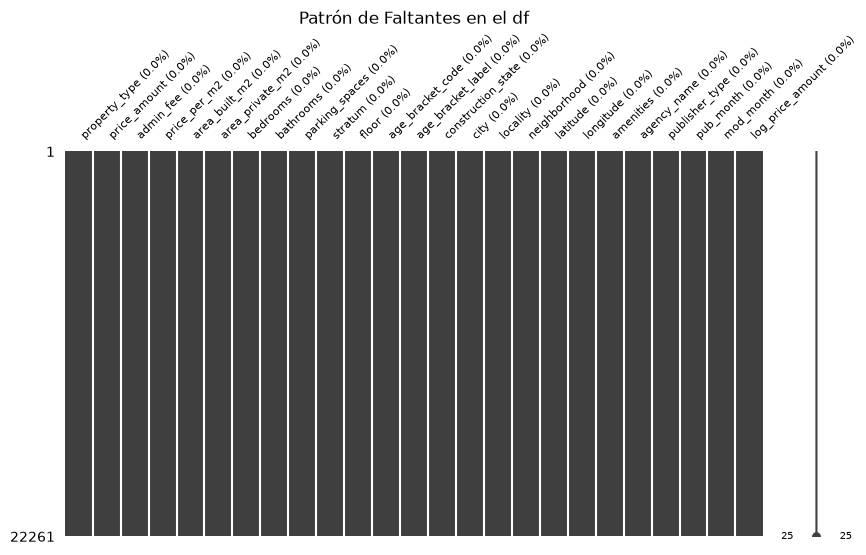

In [1078]:
n_cols = len(df.columns)
ancho = max(10, int(n_cols * 0.35))
alto = 5

tamano_letra = max(6, 10 - n_cols // 10)

# Porcentaje de nulos por columna
pct_nulos = df.isnull().mean() * 100

try:
    ax = (
        msno.matrix(df, figsize=(ancho, alto), fontsize=tamano_letra)
        or plt.gca()
    )
    plt.title("Patrón de Faltantes en el df")

    if len(ax.get_xticks()) == n_cols:
        ax.set_xticks(range(n_cols))
        ax.set_xticklabels(
            [f"{c} ({p:.1f}%)" for c, p in zip(df.columns, pct_nulos)],
            rotation=45,
            ha="left",
            fontsize=tamano_letra,
        )

    plt.show()

except Exception:
    plt.figure(figsize=(ancho, alto))
    missing_pattern = df.isnull()

    plt.imshow(missing_pattern.astype(int), aspect="auto", cmap="RdYlGn_r")

    plt.xticks(
        ticks=range(n_cols),
        labels=[
            f"{c} ({p:.1f}%)"
            for c, p in zip(missing_pattern.columns, pct_nulos)
        ],
        rotation=90,
        fontsize=tamano_letra,
        ha="center",
    )
    plt.yticks([])
    plt.title("Patrón de Faltantes (blanco = faltante)")
    plt.colorbar(label="1=Faltante, 0=Presente")

    plt.tight_layout()  # Evita que las etiquetas se corten abajo
    plt.show()

# Size comparison and inputed quantity

a little recount of modifications on data

## Dropped rows count

In [1079]:
useful_properties = initial_df[
    (initial_df["property_type"] == "casa")
    | (initial_df["property_type"] == "apartamento")
    | (initial_df["property_type"] == "apartaestudio")
    | (initial_df["property_type"] == "casa_campestre")
    | (initial_df["property_type"] == "habitacion")
    | (initial_df["property_type"] == "finca")
    | (initial_df["property_type"] == "cabana")
]

In [1080]:
initial_df.shape[0], useful_properties.shape[0], df.shape[0]

(31252, 22855, 22261)

In [1081]:

n1 = initial_df.shape[0]
n2 = useful_properties.shape[0]
n3 = df.shape[0]

tabla_comparativa = pd.DataFrame(
    [
        {
            "Comparación": "1. Inicial vs 2. Segmentación",
            "Origen (Filas)": n1,
            "Destino (Filas)": n2,
            "Diferencia Absoluta": n2 - n1,
            "Variación Porcentual (%)": ((n2 - n1) / n1) * 100
            if n1 > 0
            else 0,
            "Tasa de Retención (%)": (n2 / n1) * 100 if n1 > 0 else 0,
        },
        {
            "Comparación": "2. Segmentación vs 3. Limpieza",
            "Origen (Filas)": n2,
            "Destino (Filas)": n3,
            "Diferencia Absoluta": n3 - n2,
            "Variación Porcentual (%)": ((n3 - n2) / n2) * 100
            if n2 > 0
            else 0,
            "Tasa de Retención (%)": (n3 / n2) * 100 if n2 > 0 else 0,
        },
        {
            "Comparación": "1. Inicial vs 3. Limpieza (Total)",
            "Origen (Filas)": n1,
            "Destino (Filas)": n3,
            "Diferencia Absoluta": n3 - n1,
            "Variación Porcentual (%)": ((n3 - n1) / n1) * 100
            if n1 > 0
            else 0,
            "Tasa de Retención (%)": (n3 / n1) * 100 if n1 > 0 else 0,
        },
    ]
)


tabla_comparativa

,Comparación,Origen (Filas),Destino (Filas),Diferencia Absoluta,Variación Porcentual (%),Tasa de Retención (%)
0,1. Inicial vs 2. Segmentación,31252,22855,-8397,-26.87,73.13
1,2. Segmentación vs 3. Limpieza,22855,22261,-594,-2.60,97.40
2,1. Inicial vs 3. Limpieza (Total),31252,22261,-8991,-28.77,71.23


In [1082]:
df_etapas = pd.DataFrame(
    [
        {
            "Etapa": "1. Inicial (initial_df)",
            "Filas": n1,
            "% del Total Inicial": 100.0,
            "% Retenido Etapa Previa": 100.0,
        },
        {
            "Etapa": "2. Grupo de Interés (useful_properties)",
            "Filas": n2,
            "% del Total Inicial": (n2 / n1) * 100,
            "% Retenido Etapa Previa": (n2 / n1) * 100,
        },
        {
            "Etapa": "3. Limpieza / Final (df)",
            "Filas": n3,
            "% del Total Inicial": (n3 / n1) * 100,
            "% Retenido Etapa Previa": (n3 / n2) * 100,
        },
    ]
)
df_etapas

,Etapa,Filas,% del Total Inicial,% Retenido Etapa Previa
0,1. Inicial (initial_df),31252,100.00,100.00
1,2. Grupo de Interés (useful_properties),22855,73.13,73.13
2,3. Limpieza / Final (df),22261,71.23,97.40


Note: The loss of data in the first drop is -26.87%; however, this isn't an issue since it represents a domain selection of the target scope (households). On the other hand, note that the reduction of data because of quality problems was only -2.60%.

## Inputed quantity

In [1083]:

df_imputaciones = pd.DataFrame(
    [
        {
            'Columna': col,
            'Proporción Faltante': val[0],
            '% Faltante': val[0] * 100,
            'Método Imputación': val[1],
        }
        for col, val in filled_things.items()
    ]
).sort_values(by='% Faltante', ascending=False).reset_index(drop=True)


df_resumen_metodos = (
    df_imputaciones.groupby('Método Imputación')
    .agg(
        Cant_Columnas=('Columna', 'count'),
        Prom_Faltante_Pct=('% Faltante', 'mean'),
        Columnas=('Columna', lambda x: ', '.join(x)),
    )
    .reset_index()
    .sort_values(by='Cant_Columnas', ascending=False)
    .reset_index(drop=True)
)

print('=== DETALLE POR COLUMNA ===')
df_imputaciones



=== DETALLE POR COLUMNA ===


,Columna,Proporción Faltante,% Faltante,Método Imputación
0,floors_total,0.71,71.27,droped
1,floor,0.44,44.27,MICE
2,admin_fee,0.35,34.66,MICE
3,parking_spaces,0.26,25.53,MICE
4,area_private_m2,0.22,21.70,MICE
5,area_built_m2,0.16,15.71,MICE
6,price_per_m2,0.16,15.71,MICE
7,locality,0.12,11.84,Coordinates
8,amenities,0.08,7.82,pending
9,construction_state,0.04,4.46,mode


Se elimino total de pisos ya que la mayor parte de esta eran faltantes, ademas la variable que se inputo con mayor porcentaje de nulos fue floor.

la moda solo fue utilizada para rellenar variables cuyo porcentaje de valores nulos fuese menor al 5%

In [1084]:
print('\n=== RESUMEN POR MÉTODO DE IMPUTACIÓN ===')
df_resumen_metodos


=== RESUMEN POR MÉTODO DE IMPUTACIÓN ===


,Método Imputación,Cant_Columnas,Prom_Faltante_Pct,Columnas
0,MICE,6,26.26,"floor, admin_fee, parking_spaces, area_private..."
1,mode,6,1.73,"construction_state, age_bracket_label, stratum..."
2,bussines logic,2,4.36,"agency_name, publisher_type"
3,Coordinates,1,11.84,locality
4,KNNinputer,1,0.03,neighborhood
5,droped,1,71.27,floors_total
6,pending,1,7.82,amenities


Los metodos que mas veces se utilizaron fueron MICE y moda, sin embargo MICE lleno muchos mas valores ya que esta fue usada con variables con considerablemente mas nulos y con mecanismo MAR.


# Check outliers

In [1085]:
track_df_size_outliers = [initial_df.shape[0], useful_properties.shape[0], df.shape[0]]

In [1086]:
continuous_columns = {
    "price_amount",
    "admin_fee",
    "total_monthly_cost",
    "price_per_m2",
    "area_built_m2",
    "area_private_m2",
    "latitude",
    "longitude",
}



In [1087]:
weird_ones_extreme = find_weird_properties_per_loc(df, locality_treatment)

In [1088]:
weird_ones_extreme.sum() # those rows were already cleaned

np.int64(0)

## Basic bussines rules

Note: first we use this kind of rules due to the scale of the upper outliers, if we use 1.5*IQR first the lower limit will be something < 0. Therefore the columns would not be completely clean.

In [1089]:
continuous_columns_rules = {
    "price_amount": lambda x: not(30_000_000 < x < 1_000_000_000_000),
    "admin_fee": lambda x: x < 0,
    "total_monthly_cost": lambda x: False,
    "price_per_m2": lambda x: False,
    "area_built_m2": lambda x: not(10 < x < 5_000),
    "area_private_m2": lambda x: not(10 < x < 5_000),
    "latitude": lambda x: False,
    "longitude": lambda x: False,
}

In [1090]:
for k, v in continuous_columns_rules.items():
    if k in df.columns:
        print(f"there is any foundational issue in {k}: {df[k].apply(v).any()}")
        print()

there is any foundational issue in price_amount: True

there is any foundational issue in admin_fee: False

there is any foundational issue in price_per_m2: False

there is any foundational issue in area_built_m2: True

there is any foundational issue in area_private_m2: True

there is any foundational issue in latitude: False

there is any foundational issue in longitude: False



### Bussines outliers for price_amount

In [1091]:
df[df["price_amount"] < 30_000_000].head()

,property_type,price_amount,admin_fee,price_per_m2,area_built_m2,area_private_m2,bedrooms,bathrooms,parking_spaces,stratum,...,locality,neighborhood,latitude,longitude,amenities,agency_name,publisher_type,pub_month,mod_month,log_price_amount
330,apartamento,1450000.00,800000.00,6680393.81,123.00,154.00,3.00,3.00,3,6.00,...,Usaquen,Santa Barbara Central,4.70,-74.04,Balcón|Barra estilo americano|Baño Auxiliar|Ba...,GRUPO A12 Expertos Inmobiliarios,inmobiliaria,2024-02,2026-06,14.19
3888,casa,1710000.00,535954.00,3279559.85,163.52,144.91,4.00,2.00,2,5.00,...,Suba,Ilarco,4.70,-74.07,Citófono|Cocina Integral|Jardín|Piso en Alfomb...,Recorridos Inmobiliarios,inmobiliaria,2025-06,2026-06,14.35
4358,apartamento,1820000.00,975000.00,10400.00,175.00,175.00,2.00,3.00,4,6.00,...,Suba,Gratamira,4.74,-74.08,Acceso Pavimentado|Asador|Ascensor|Balcón|Baño...,AU BROKER,inmobiliaria,2025-07,2026-07,14.41
6019,casa,1300000.00,1008000.00,3656910.86,159.06,164.00,3.00,3.00,2,5.00,...,Suba,Vereda Suba Naranjos,4.73,-74.08,Balcón|Calentador|Cerca centro comercial|Chime...,G15 Grupo Inmobiliario,inmobiliaria,2025-10,2026-07,14.08
7488,casa,11111111.00,10668947.98,21375.74,519.80,519.80,16.00,9.00,3,3.00,...,San Cristobal,UB. Parque Metropolitano,4.57,-74.09,Ninguna,Particular / Venta Directa,Particular,2025-12,2026-07,16.22


In [1092]:
df[df["price_amount"] > 1_000_000_000_000]

,property_type,price_amount,admin_fee,price_per_m2,area_built_m2,area_private_m2,bedrooms,bathrooms,parking_spaces,stratum,...,locality,neighborhood,latitude,longitude,amenities,agency_name,publisher_type,pub_month,mod_month,log_price_amount
6913,apartamento,1250000000000.00,1560000.00,6097560975.61,205.00,11246.76,3.00,4.00,4,6.00,...,Usaquen,Bosque DE Pinos,4.72,-74.02,Alarma Contra Incendio|Baño Auxiliar|Calentado...,Carrizosa Hermanos Ltda,inmobiliaria,2025-12,2026-06,27.85


In [1093]:
with pd.option_context('display.max_colwidth', None):
    display(initial_df[initial_df["price_amount"] == 1250000000000][["source_url", "property_type"]])

,source_url,property_type
10415,https://www.fincaraiz.com.co/apartamento-en-venta-en-bosques-del-marques-bogota/193171170,apartamento
24328,https://www.fincaraiz.com.co/casa-en-venta-en-belalcazar-bogota/193872635,casa


In [1094]:
df = df[df["price_amount"].between(30_000_000, 1_000_000_000_000)]

In [1095]:
track_df_size_outliers.append(df.shape[0])

In [1096]:
track_df_size_outliers

[31252, 22855, 22261, 22248]

### Bussines outliers for area_built_m2 and area_private_m2

In [1097]:
(df["area_built_m2"] < 10).sum(), (df["area_built_m2"] > 5000).sum()

(np.int64(9), np.int64(47))

In [1098]:
(df["area_private_m2"] < 10).sum(), (df["area_private_m2"] > 5000).sum()

(np.int64(9), np.int64(47))

In [1099]:
df = df[df["area_private_m2"].between(10, 5000, inclusive='neither')]

In [1100]:
df = df[df["area_built_m2"].between(10, 5000, inclusive='neither')]

In [1101]:
track_df_size_outliers.append(df.shape[0])

In [1102]:
track_df_size_outliers

[31252, 22855, 22261, 22248, 22148]

In [1103]:
for k, v in continuous_columns_rules.items():
    if k in df.columns:
        print(f"there is any foundational issue in {k}: {df[k].apply(v).any()}")
        print()

there is any foundational issue in price_amount: False

there is any foundational issue in admin_fee: False

there is any foundational issue in price_per_m2: False

there is any foundational issue in area_built_m2: False

there is any foundational issue in area_private_m2: False

there is any foundational issue in latitude: False

there is any foundational issue in longitude: False



## Clean using IQR

In [1104]:
cols_to_clean = continuous_columns = {
    "price_amount",
    "admin_fee",
    "price_per_m2",
    "area_built_m2",
    "area_private_m2"
}

In [1105]:
df = df[df["price_amount"] != df["price_amount"].max()]

In [1106]:
df["admin_fee"].max()

np.float64(2147483647.0)

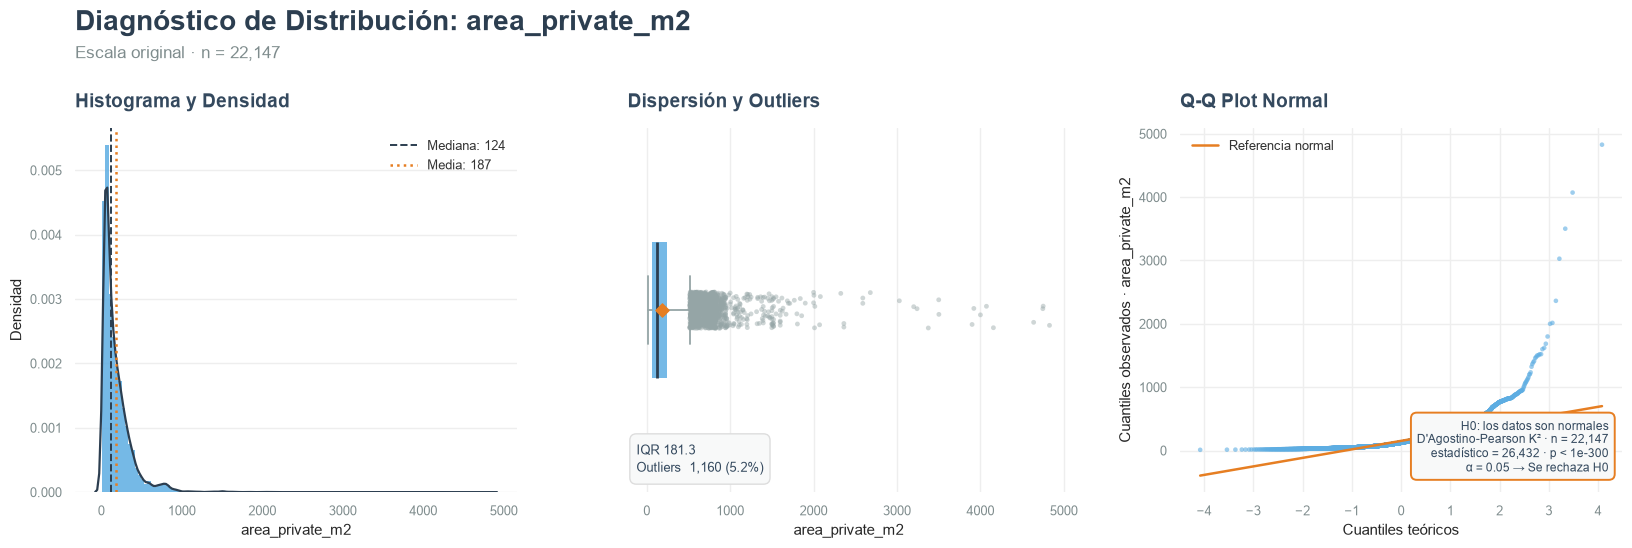

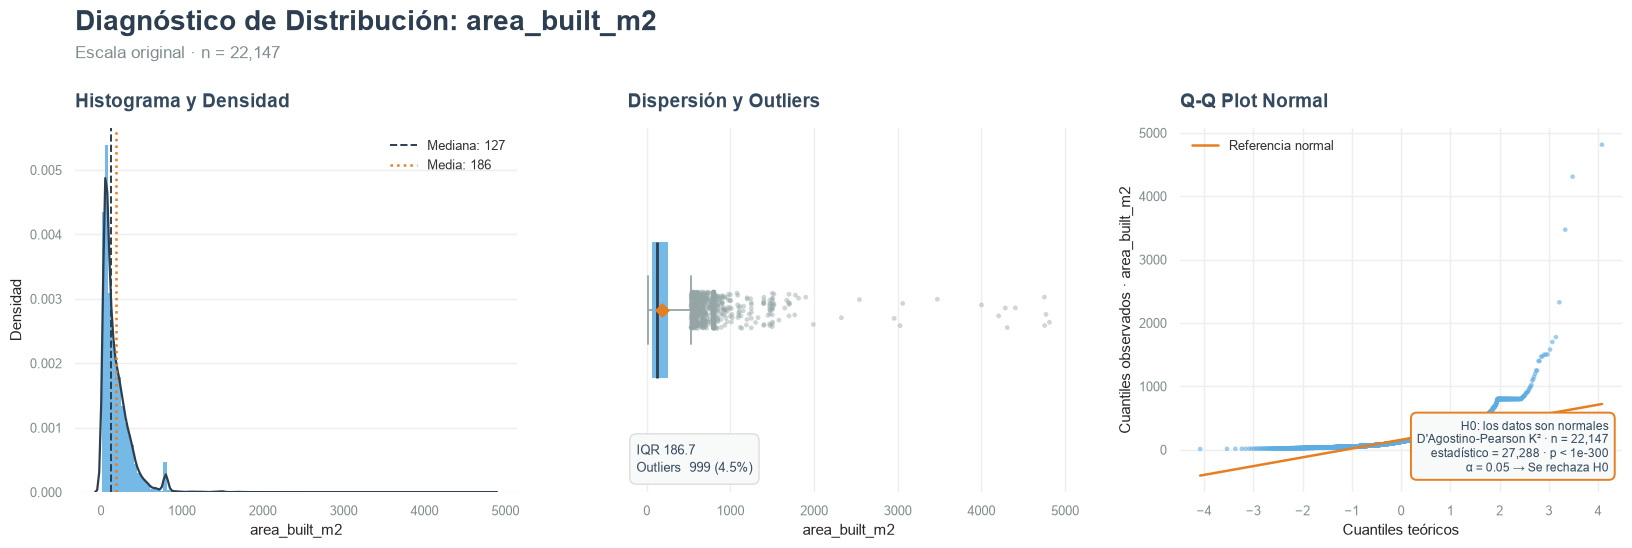

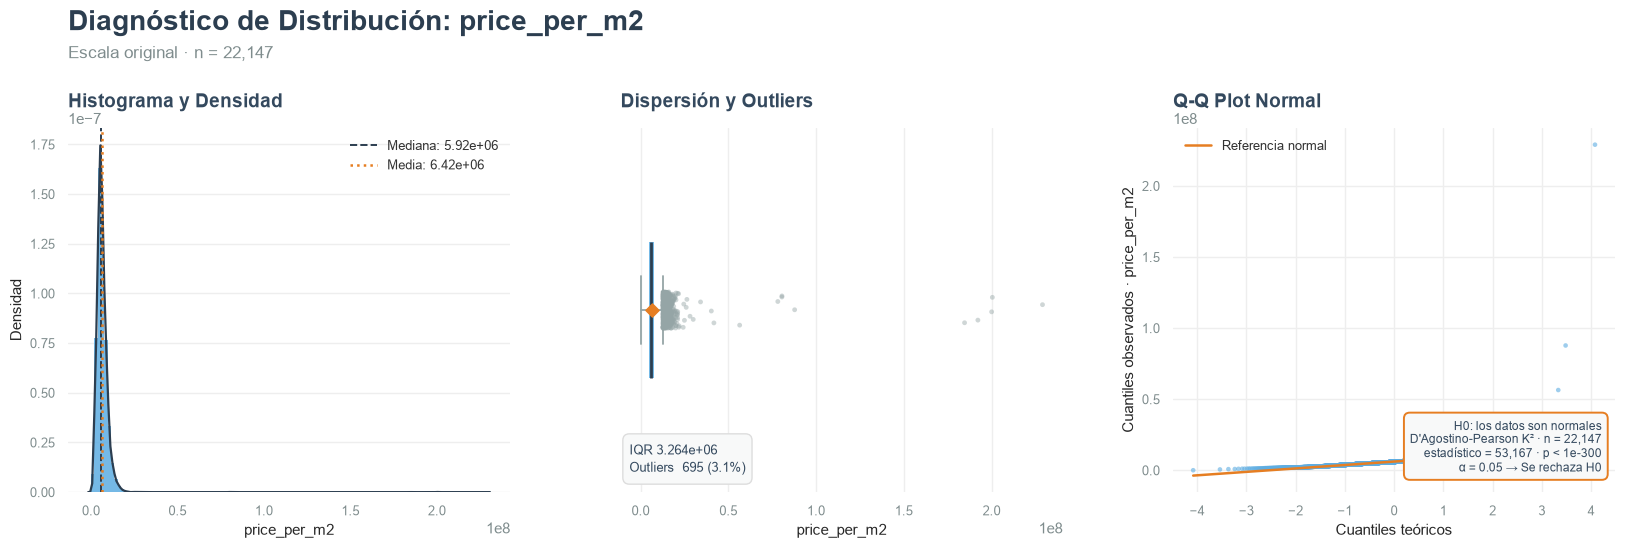

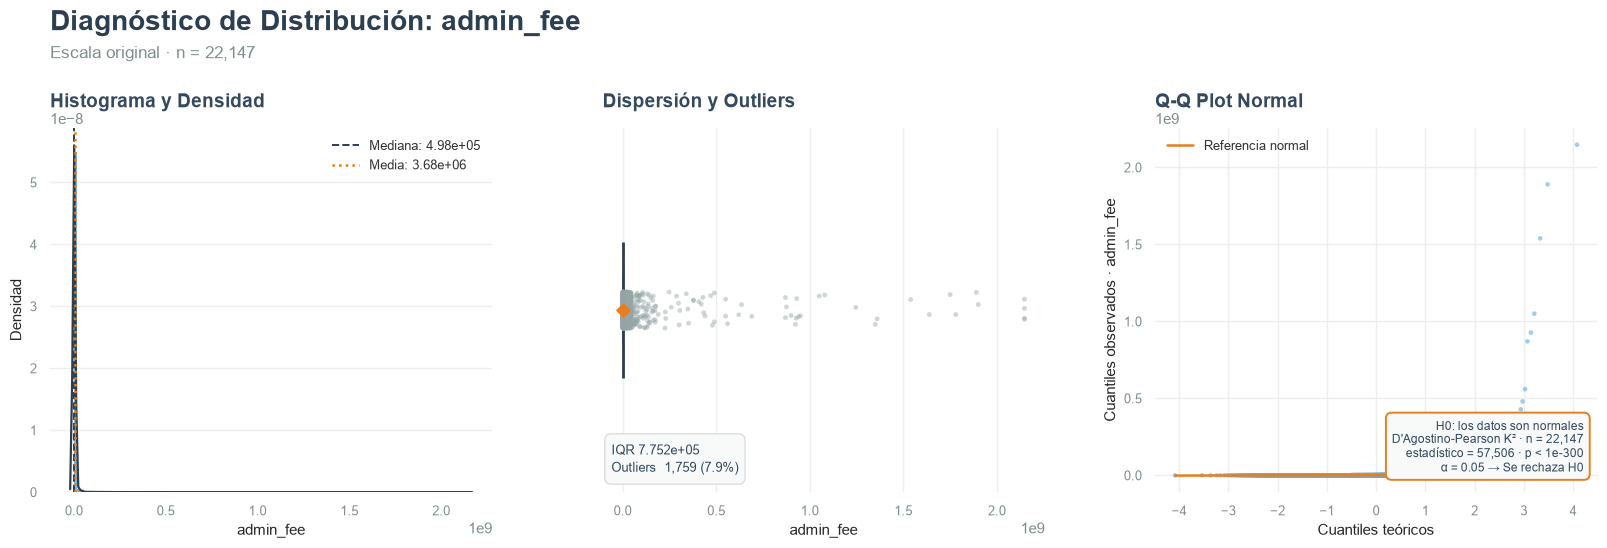

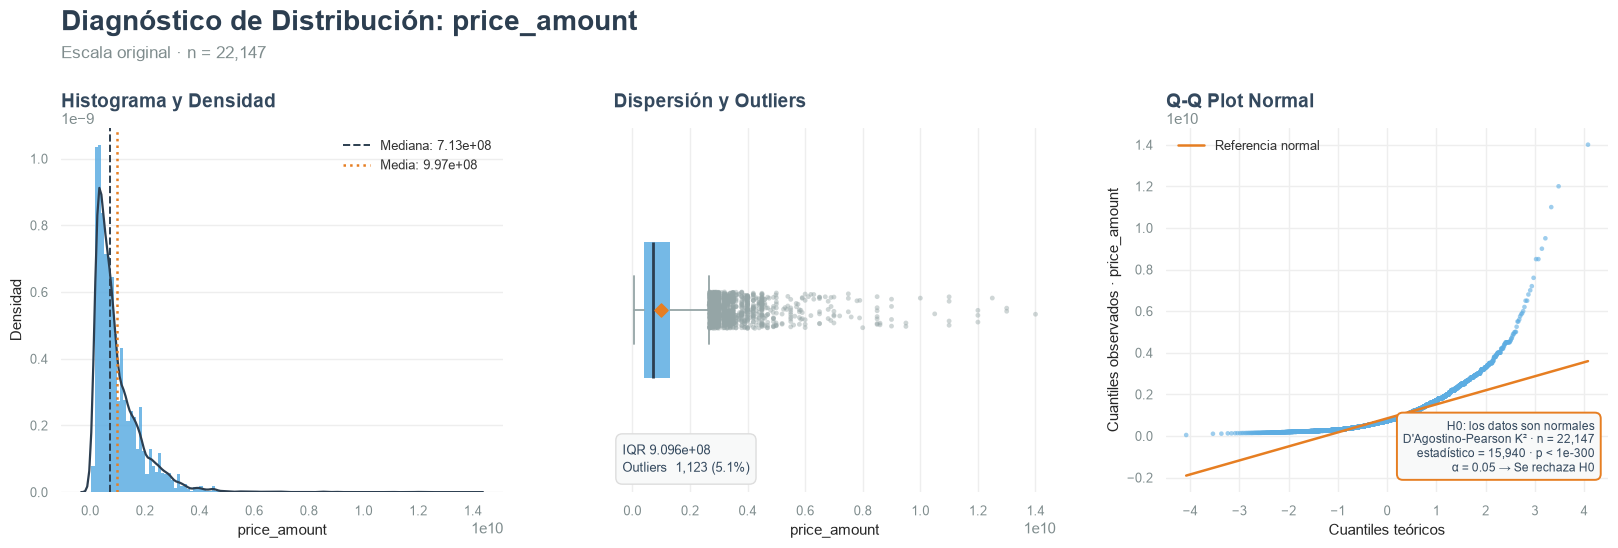

In [1107]:
for col in cols_to_clean:
    normality_report(df, col)

Just by using a basic cleaning the variables are singnificantly better than before, look how now the distributions are now readable, now lets go ahead with more complex cleaning. The most of ilogic values are already cleaned.

In [1108]:
def resume_limits(df=df, cols_to_clean=cols_to_clean, extreme=False):
    iqr_summary = []

    for col in cols_to_clean:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        mult = 3 if extreme else 1.5

        lower = Q1 - mult * IQR
        upper = Q3 + mult * IQR

        iqr_summary.append(
            {
                "columna": col,
                "limite_inferior": lower,
                "limite_superior": upper,
                "Q1": Q1,
                "Q3": Q3,
                "IQR": IQR,
            }
        )

    df_iqr_limits = pd.DataFrame(iqr_summary)
    return df_iqr_limits

resume_limits()

,columna,limite_inferior,limite_superior,Q1,Q3,IQR
0,area_private_m2,-210.19,514.91,61.72,243.00,181.28
1,area_built_m2,-217.11,529.85,63.00,249.74,186.74
2,price_per_m2,-371973.10,12683447.22,4523809.52,7787664.60,3263855.08
3,admin_fee,-937893.60,2162736.16,224842.56,1000000.00,775157.44
4,price_amount,-973990750.00,2664394450.00,390403700.00,1300000000.00,909596300.00


Since those upper limits can left outside luxury properties we are going to consider extreme outliers (3 * IQR)

In [1109]:
extreme_outs_thresholds = resume_limits(extreme=True)
extreme_outs_thresholds

,columna,limite_inferior,limite_superior,Q1,Q3,IQR
0,area_private_m2,-482.10,786.83,61.72,243.00,181.28
1,area_built_m2,-497.23,809.97,63.00,249.74,186.74
2,price_per_m2,-5267755.72,17579229.84,4523809.52,7787664.60,3263855.08
3,admin_fee,-2100629.76,3325472.32,224842.56,1000000.00,775157.44
4,price_amount,-2338385200.00,4028788900.00,390403700.00,1300000000.00,909596300.00


In [1110]:
def count_outliers_from_limits(df_data, df_limits):

    result_df = df_limits.copy()

    outlier_counts = []
    outlier_pcts = []

    for _, row in result_df.iterrows():
        col = row["columna"]
        lower = row["limite_inferior"]
        upper = row["limite_superior"]

        if col in df_data.columns:
            is_outlier = (df_data[col] < lower) | (df_data[col] > upper)
            count = is_outlier.sum()
            pct = (count / len(df_data)) * 100
        else:
            count = 0
            pct = 0.0

        outlier_counts.append(count)
        outlier_pcts.append(round(pct, 2))

    result_df["outliers_count"] = outlier_counts
    result_df["outliers_pct"] = outlier_pcts

    return result_df

count_outliers_from_limits(df, extreme_outs_thresholds)[["columna", "outliers_count", "outliers_pct"]]

,columna,outliers_count,outliers_pct
0,area_private_m2,431,1.95
1,area_built_m2,158,0.71
2,price_per_m2,81,0.37
3,admin_fee,1107,5.00
4,price_amount,235,1.06


the column which have the most outliers only have a 5%, due to this we will drop the outlier rows

In [1111]:
def remove_outliers(df_data, df_limits):

    df_clean = df_data.copy()

    valid_mask = pd.Series(True, index=df_clean.index)

    for _, row in df_limits.iterrows():
        col = row['columna']
        lower = row['limite_inferior']
        upper = row['limite_superior']

        if col in df_clean.columns:
            col_mask = (df_clean[col] >= lower) & (df_clean[col] <= upper)
            valid_mask &= col_mask

    df_filtered = df_clean[valid_mask].copy()

    df_final = df_filtered.copy()

    rows_before = len(df_data)
    rows_after = len(df_final)
    rows_dropped = rows_before - rows_after
    pct_dropped = (rows_dropped / rows_before) * 100

    print("=== REPORTE DE LIMPIEZA ===")
    print(f"Filas originales: {rows_before}")
    print(f"Filas finales:    {rows_after}")
    print(f"Filas eliminadas: {rows_dropped} ({pct_dropped:.2f}%)")

    return df_final

df = remove_outliers(df, extreme_outs_thresholds)

=== REPORTE DE LIMPIEZA ===
Filas originales: 22147
Filas finales:    20442
Filas eliminadas: 1705 (7.70%)


In [1112]:
track_df_size_outliers.append(df.shape[0])

In [1113]:
track_df_size_outliers

[31252, 22855, 22261, 22248, 22148, 20442]

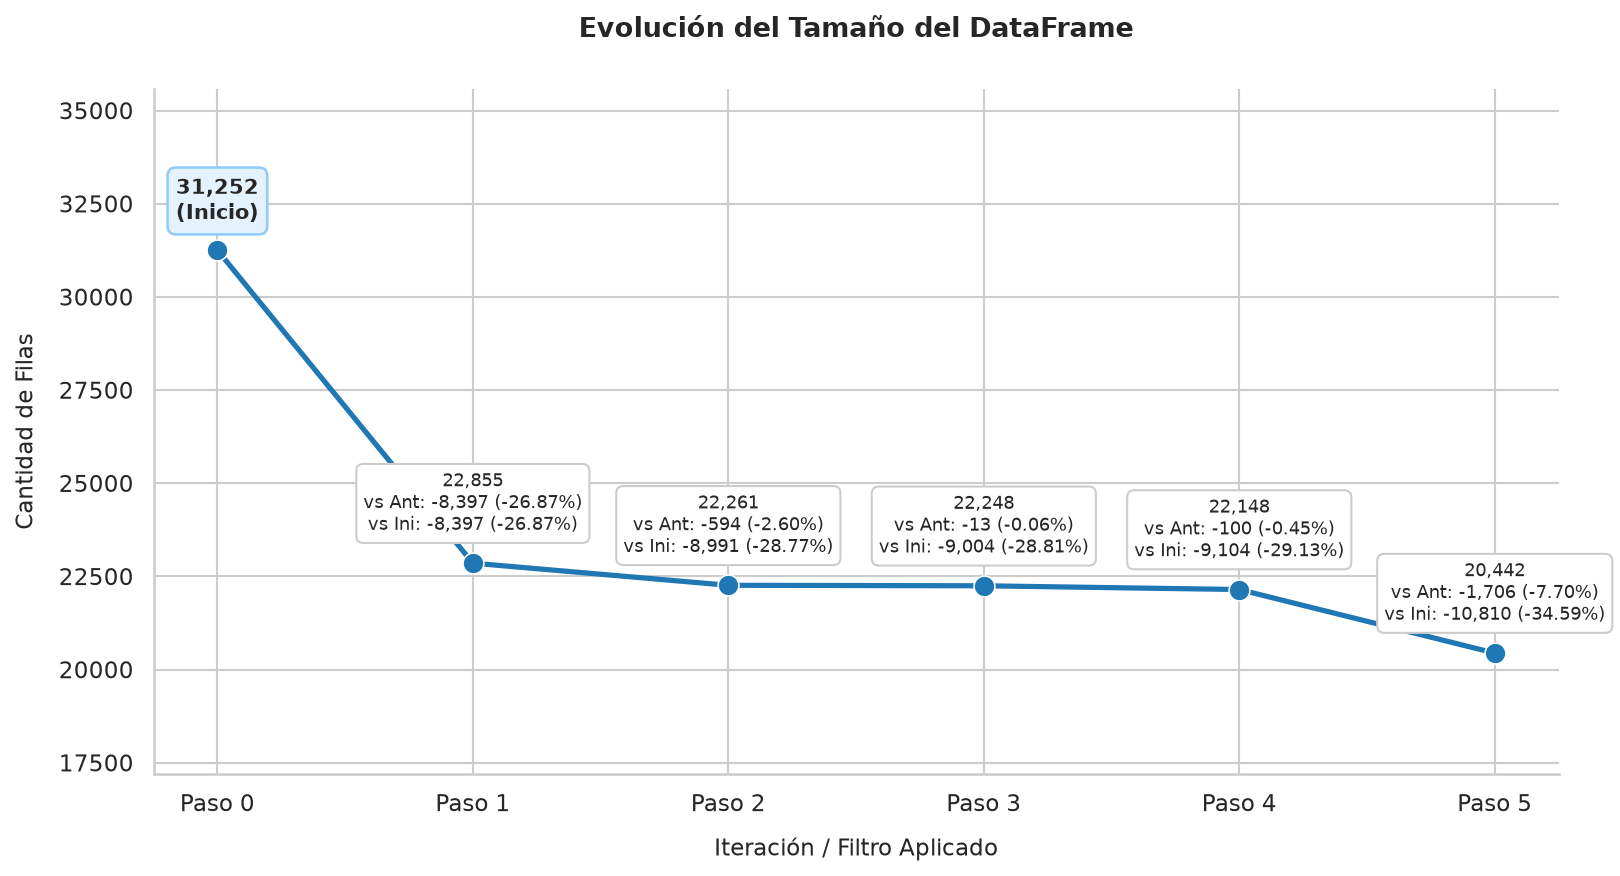

In [1115]:
# Configuración de estilo moderno con Seaborn
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

fig, ax = plt.subplots(figsize=(11, 6), dpi=150)

n = len(track_df_size_outliers)
x = np.arange(n)
y = np.array(track_df_size_outliers)

# 1. Dibujar la línea principal y los puntos
sns.lineplot(
    x=x,
    y=y,
    marker="o",
    markersize=10,
    linewidth=2.5,
    color="#1f77b4",
    ax=ax,
)

first_val = y[0]

# 2. Agregar etiquetas interactivas en cada punto
for i in range(n):
    val = y[i]

    if i == 0:
        # Primer punto (referencia)
        label = f"**{val:,}**\n(Inicio)"
        ax.annotate(
            f"{val:,}\n(Inicio)",
            (x[i], y[i]),
            textcoords="offset points",
            xytext=(0, 15),
            ha="center",
            fontsize=10,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.4",
                fc="#e3f2fd",
                ec="#90caf9",
                lw=1.2,
            ),
        )
    else:
        # Puntos posteriores: calcular reducciones
        prev_val = y[i - 1]

        # Respecto al anterior
        diff_prev = val - prev_val
        pct_prev = (diff_prev / prev_val) * 100

        # Respecto al primero
        diff_first = val - first_val
        pct_first = (diff_first / first_val) * 100

        label = (
            f"{val:,}\n"
            f"vs Ant: {diff_prev:+,} ({pct_prev:+.2f}%)\n"
            f"vs Ini: {diff_first:+,} ({pct_first:+.2f}%)"
        )

        ax.annotate(
            label,
            (x[i], y[i]),
            textcoords="offset points",
            xytext=(0, 16),
            ha="center",
            fontsize=8.5,
            bbox=dict(
                boxstyle="round,pad=0.4",
                fc="#ffffff",
                ec="#cccccc",
                lw=1,
            ),
        )

# 3. Estética y títulos
ax.set_title(
    "Evolución del Tamaño del DataFrame",
    fontsize=13,
    fontweight="bold",
    pad=25,
)
ax.set_xlabel("Iteración / Filtro Aplicado", fontsize=11, labelpad=10)
ax.set_ylabel("Cantidad de Filas", fontsize=11, labelpad=10)

ax.set_xticks(x)
ax.set_xticklabels([f"Paso {i}" for i in range(n)])

# Dar margen vertical para que las cajas de texto no se corten
y_margin = (max(y) - min(y)) if max(y) != min(y) else max(y) * 0.1
ax.set_ylim(min(y) - y_margin * 0.3, max(y) + y_margin * 0.4)

# Quitar bordes innecesarios
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

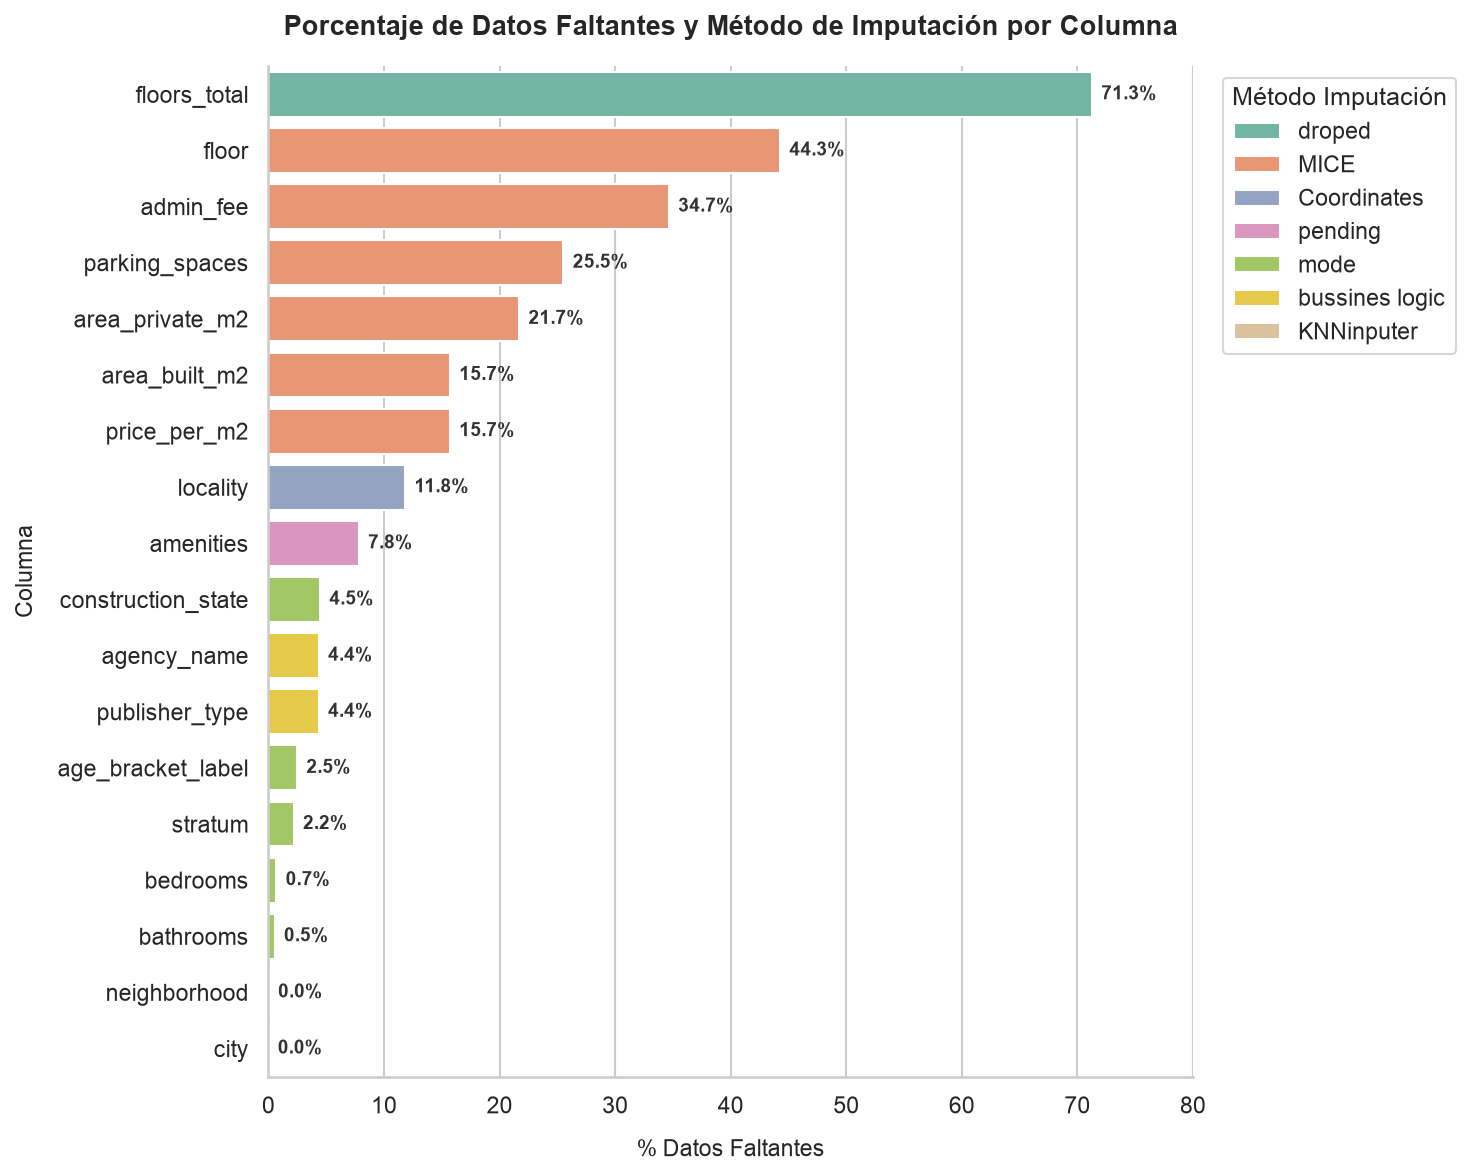

In [1117]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 8), dpi=150)

# 1. Crear el gráfico de barras horizontal ordenado
barplot = sns.barplot(
    data=df_imputaciones,
    x="% Faltante",
    y="Columna",
    hue="Método Imputación",
    dodge=False,  # Mantiene las barras alineadas al eje Y
    palette="Set2",
    ax=ax,
)

# 2. Agregar el porcentaje exacto al final de cada barra
for p in barplot.patches:
    width = p.get_width()
    if width > 0:  # Evita anotar en barras de valor ~0 no visibles
        ax.annotate(
            f"{width:.1f}%",
            (width + 0.8, p.get_y() + p.get_height() / 2.0),
            ha="left",
            va="center",
            fontsize=9,
            color="#333333",
            fontweight="bold",
        )

# 3. Personalización de ejes, títulos y leyenda
ax.set_title(
    "Porcentaje de Datos Faltantes y Método de Imputación por Columna",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("% Datos Faltantes", fontsize=11, labelpad=10)
ax.set_ylabel("Columna", fontsize=11, labelpad=10)
ax.set_xlim(0, 80)  # Margen extra a la derecha para las etiquetas

# Leyenda
plt.legend(
    title="Método Imputación",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    facecolor="white",
)

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

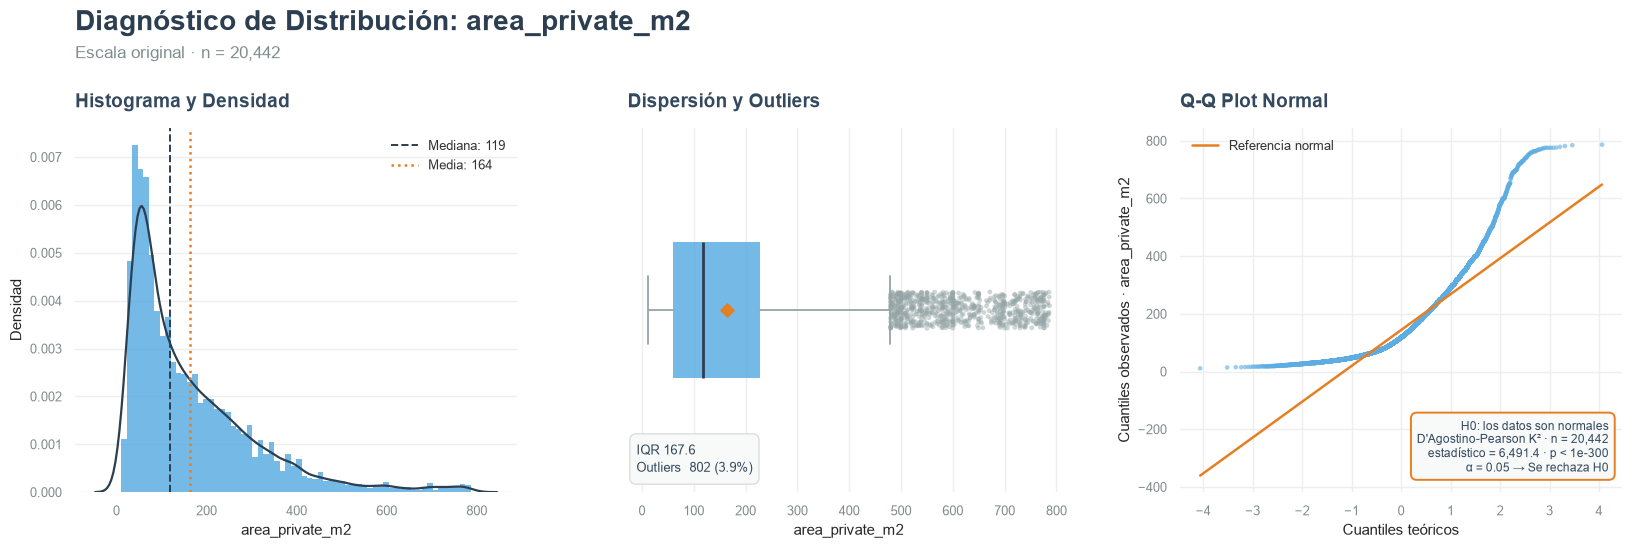

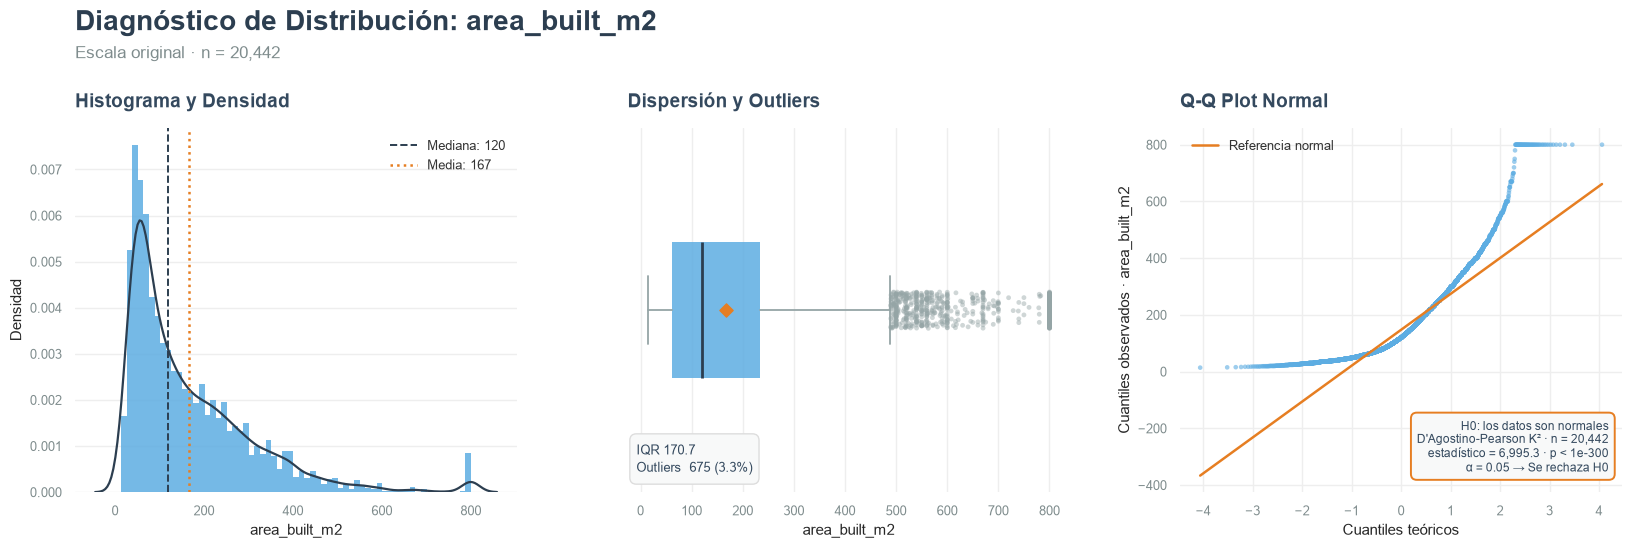

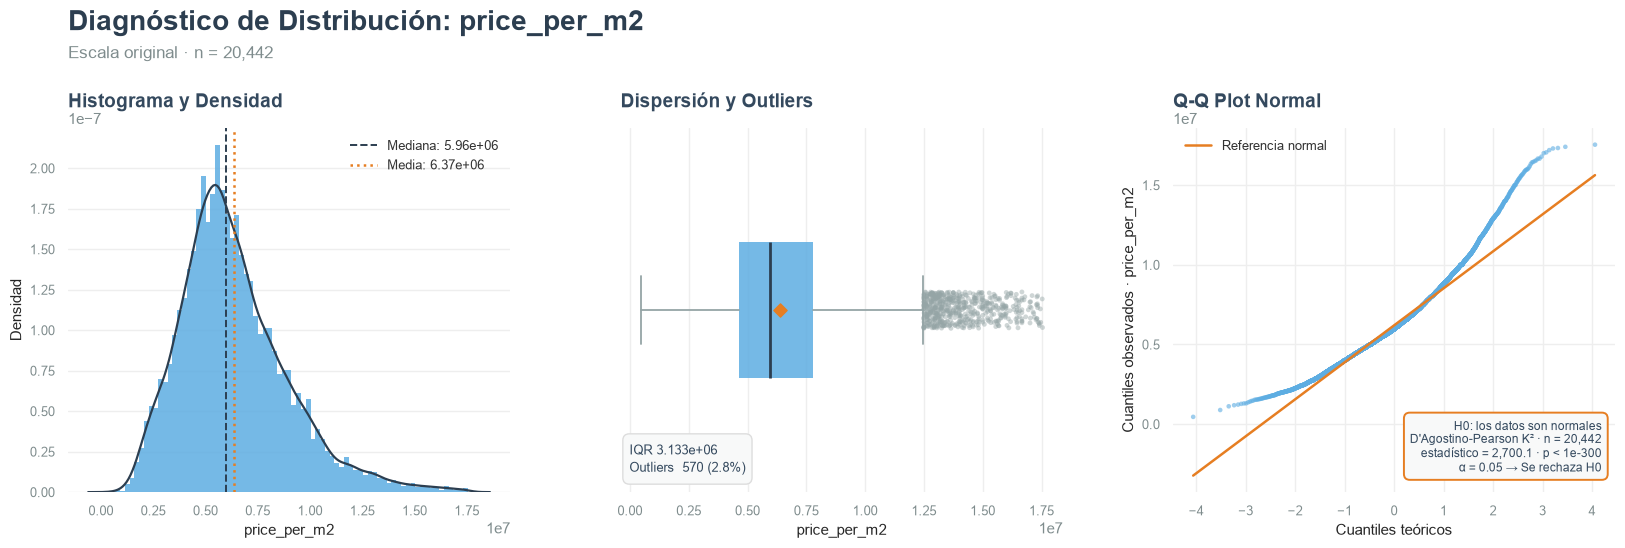

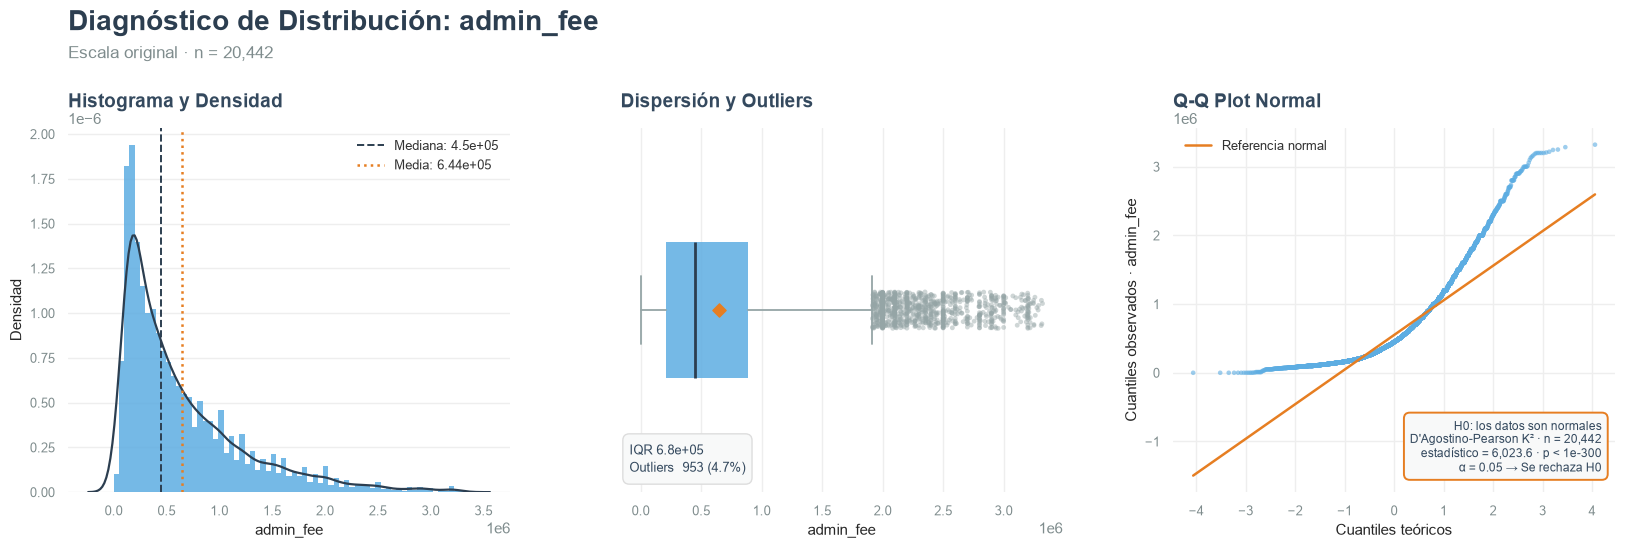

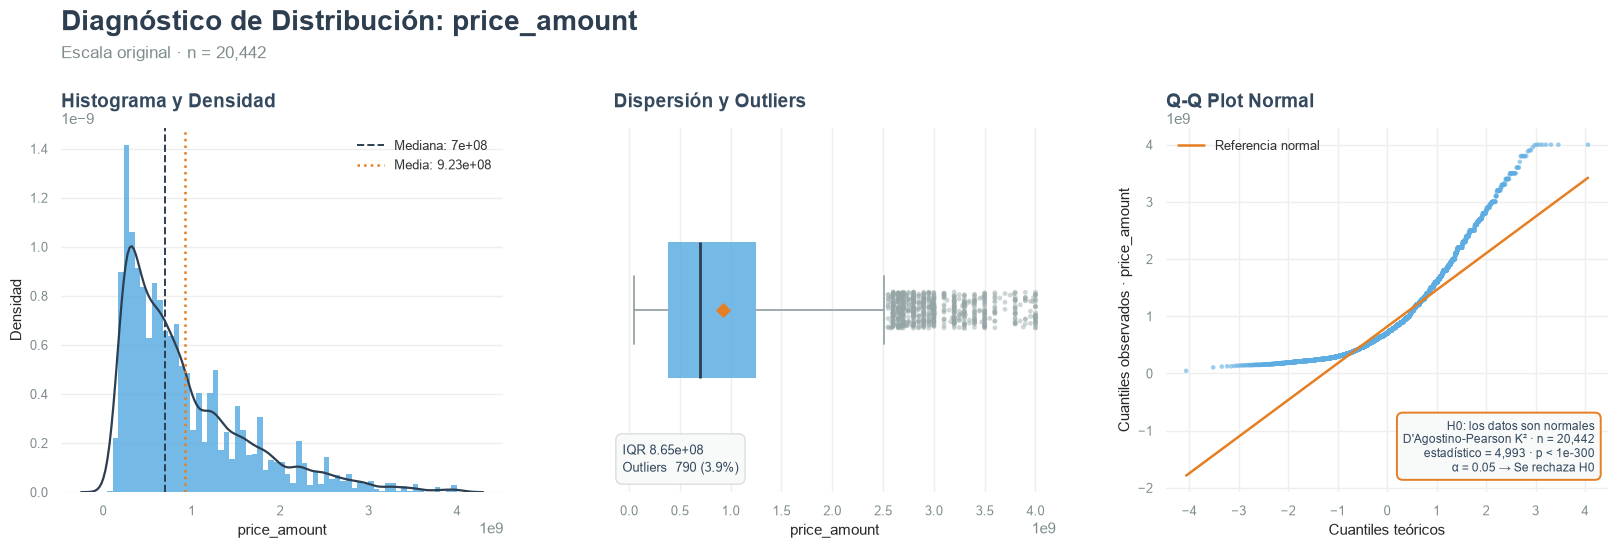

In [1116]:
for col in cols_to_clean:
    normality_report(df, col)